In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Pipeline Steps:
1. Data Set Info
2. EDA
3. Data Cleaning & Missing Imputation
5. Features Engineering
6. Feature Selection
7. Modeling & Evaluation
8. Model selection
9. Prediction and submission 
   
   

# 1. Data Set Info

In [2]:
import pandas as pd

In [3]:
def Load_and_Info_DataSet(dataSetPath):
    DataSet = pd.read_csv(dataSetPath)
    print('-'*50,"\nDataSet Shape:")
    display(DataSet.shape)
    print('-'*50,'\nDataSet Columns:')
    display(DataSet.columns)
    print('-'*50,'\nDataSet Describe:')
    display(DataSet.describe(include='all'))
    print('-'*50,'\nMissing Percentages:')
    display(DataSet.isnull().mean()*100)
    print('-'*50,'\nDataSet Sample:')
    display(DataSet.sample(15))
    print('-'*50,'\nDataSet Info:')
    display(DataSet.info())
    return DataSet

In [4]:
DataSet = Load_and_Info_DataSet('/kaggle/input/titanic/train.csv')

-------------------------------------------------- 
DataSet Shape:


(891, 12)

-------------------------------------------------- 
DataSet Columns:


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

-------------------------------------------------- 
DataSet Describe:


...

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

-------------------------------------------------- 
DataSet Sample:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
607,608,1,1,"Daniel, Mr. Robert Williams",male,27.0,0,0,113804,30.5000,NaN,S
835,836,1,1,"Compton, Miss. Sara Rebecca",female,39.0,1,1,PC 17756,83.1583,E49,C
260,261,0,3,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.7500,NaN,Q
828,829,1,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
361,362,0,2,"del Carlo, Mr. Sebastiano",male,29.0,1,0,SC/PARIS 2167,27.7208,NaN,C
114,115,0,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
574,575,0,3,"Rush, Mr. Alfred George John",male,16.0,0,0,A/4. 20589,8.0500,NaN,S
684,685,0,2,"Brown, Mr. Thomas William Solomon",male,60.0,1,1,29750,39.0000,NaN,S


-------------------------------------------------- 
DataSet Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None

# 2. EDA

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt 

In [6]:
def features_EDA_with_Plots(DataSet, target):
    print(f'Features\' univatiate analysis and bivariate with target : {target}')
    for cols in DataSet.columns:
        print('_'*50,f'\n{cols}')
        sns.displot(DataSet,x=cols)
        plt.show()
        sns.displot(DataSet,x=cols,hue=target)
        plt.show()
        sns.boxplot(DataSet,x=cols)
        plt.show()
        sns.boxplot(DataSet,x=cols,hue=target)
        plt.show()
        sns.violinplot(DataSet,x=cols)
        plt.show()
        sns.violinplot(DataSet,x=cols,hue=target)
        plt.show()

        
        

Features' univatiate analysis and bivariate with target : Survived
__________________________________________________ 
PassengerId


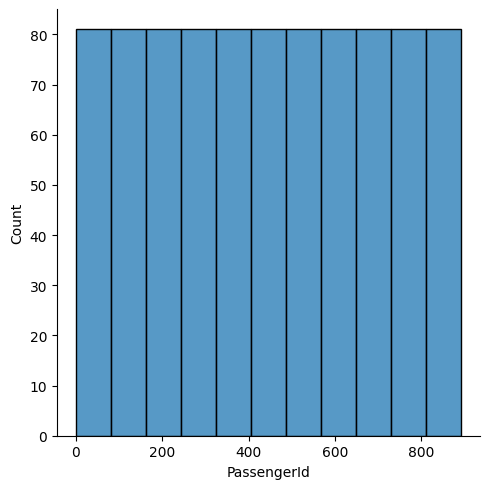

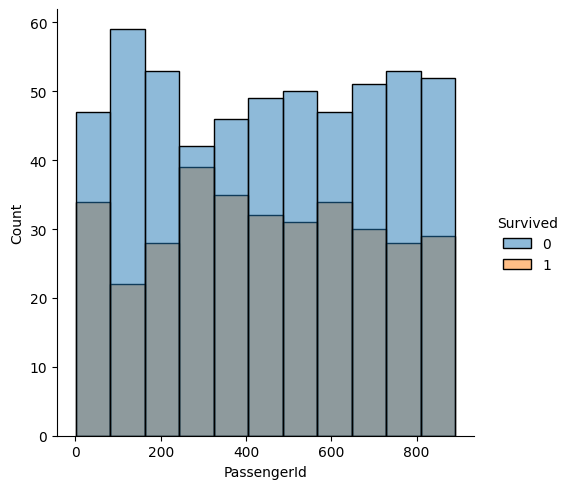

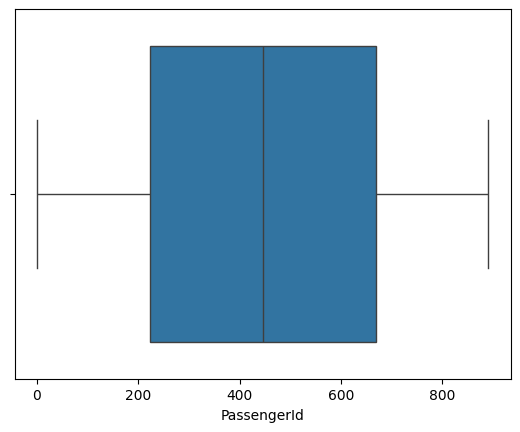

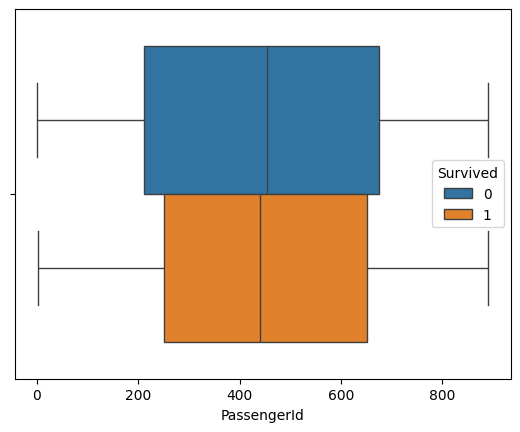

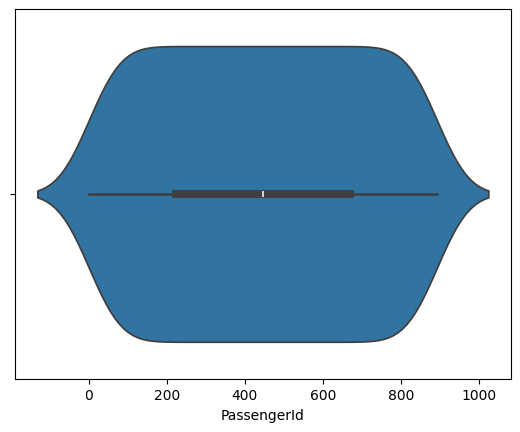

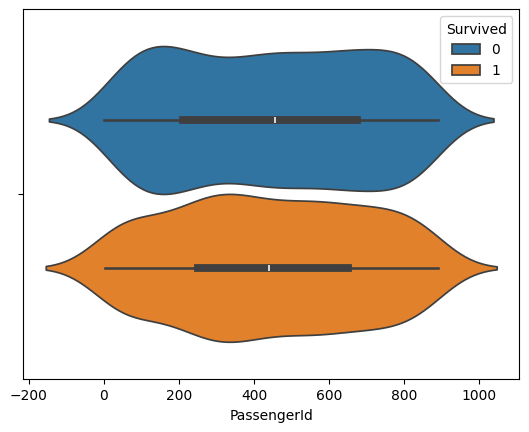

__________________________________________________ 
Survived


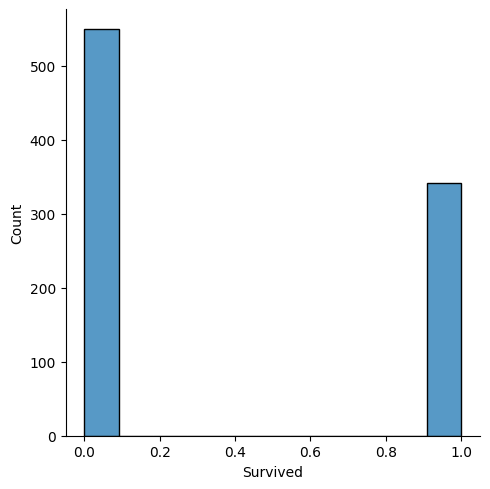

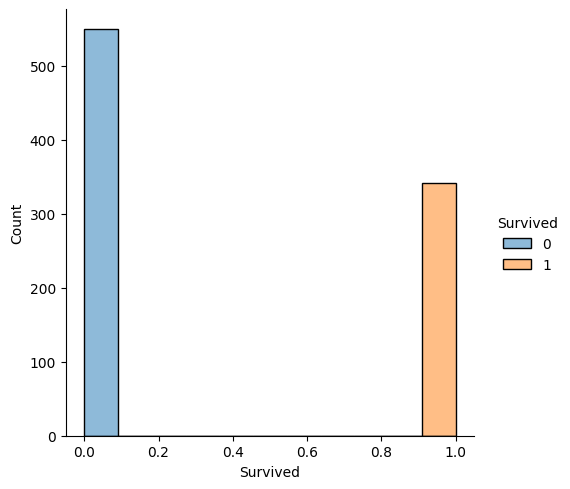

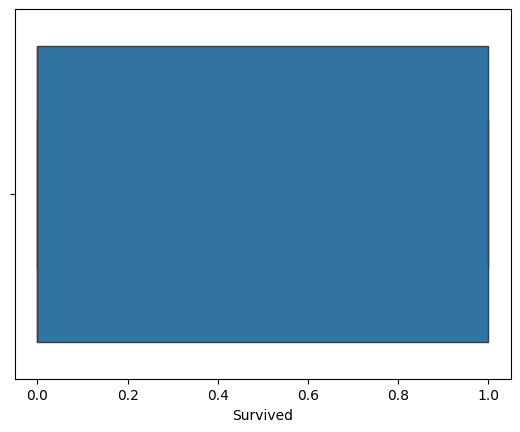

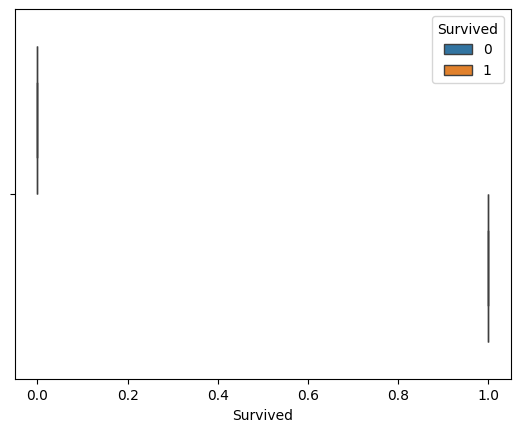

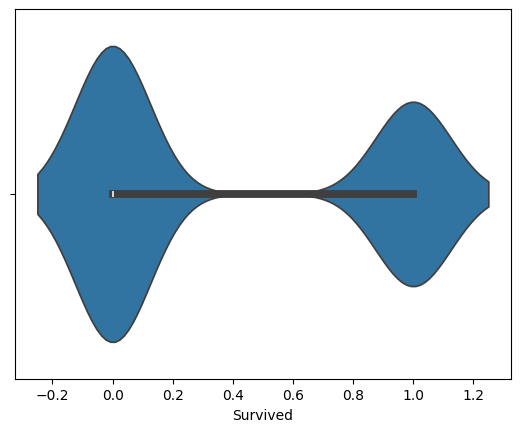

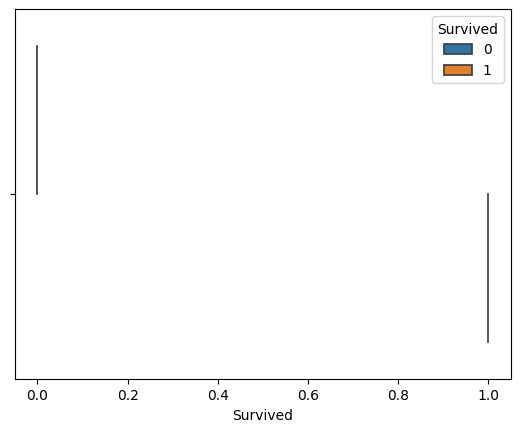

__________________________________________________ 
Pclass


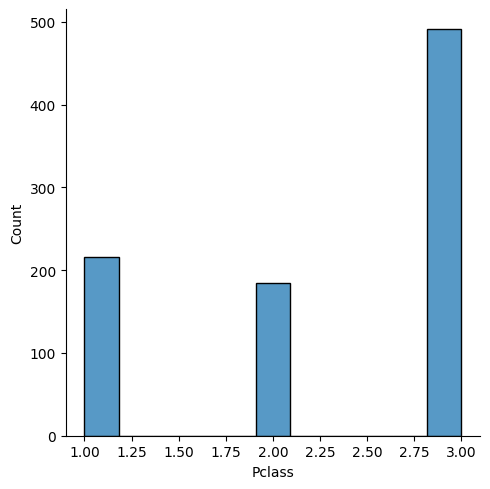

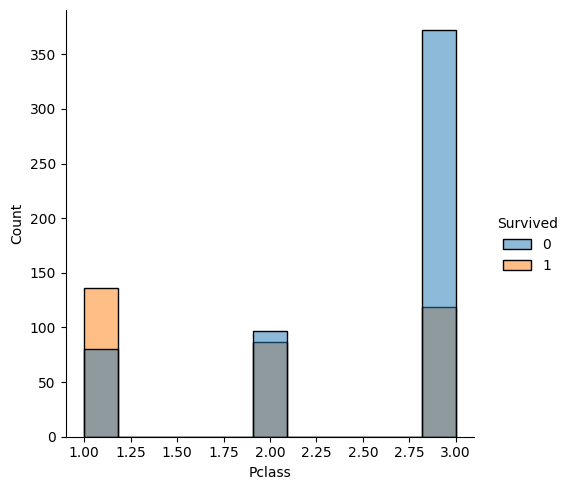

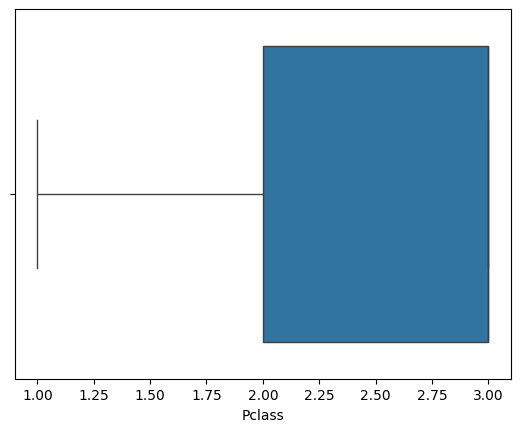

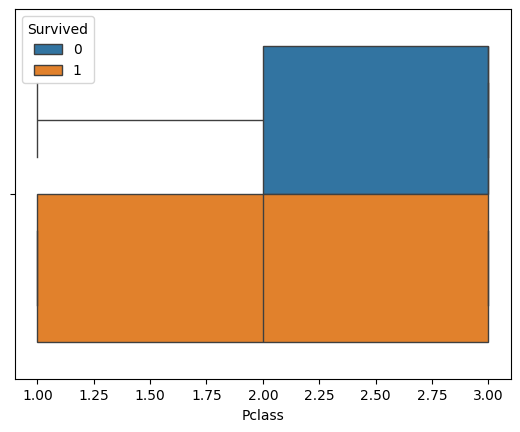

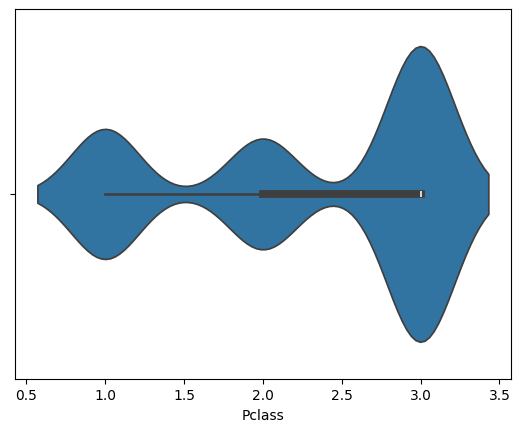

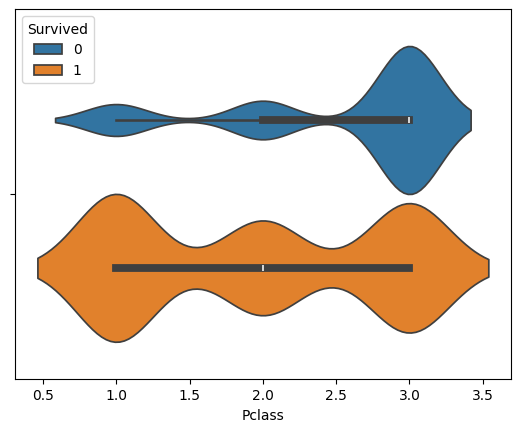

__________________________________________________ 
Name


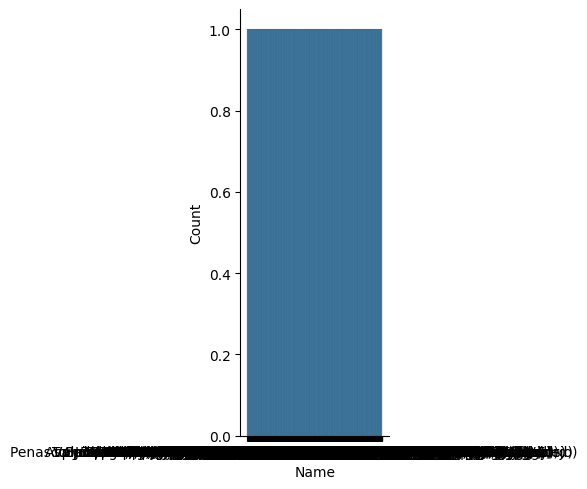

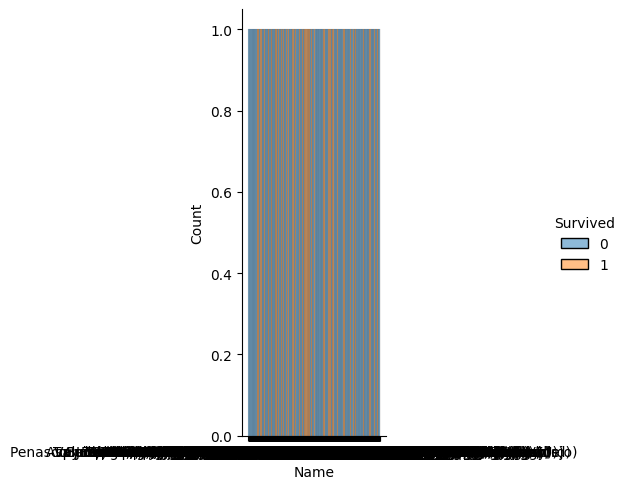

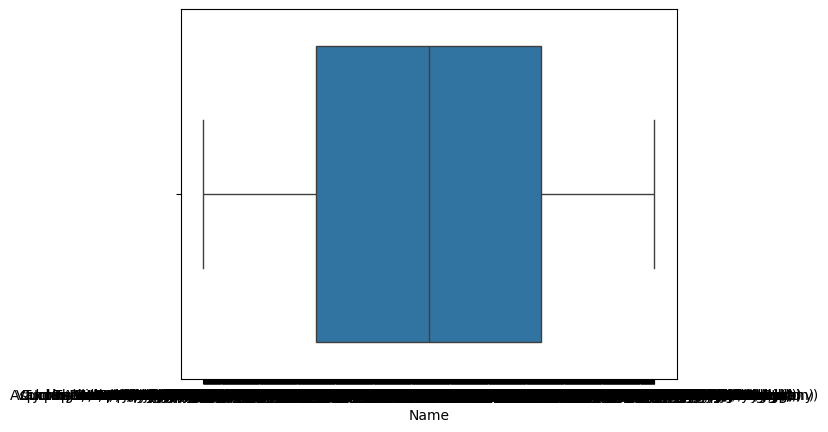

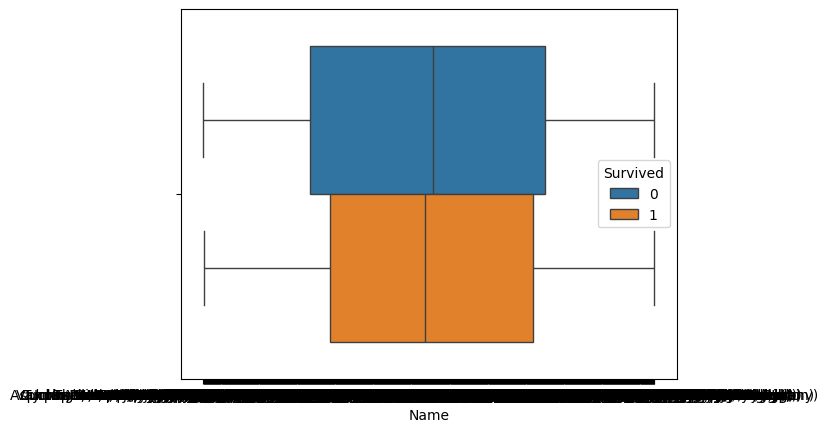

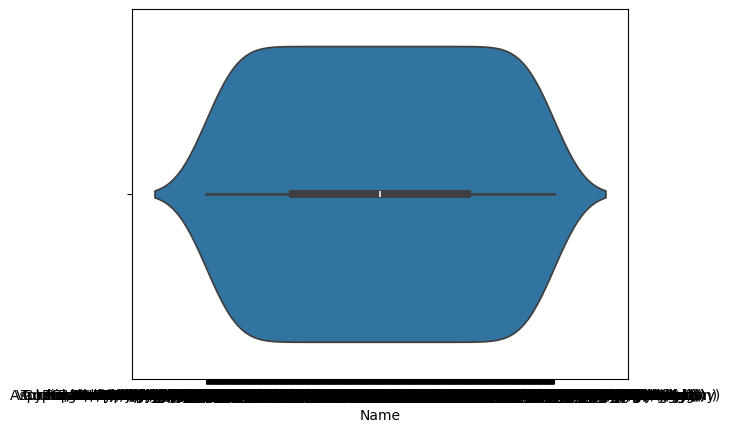

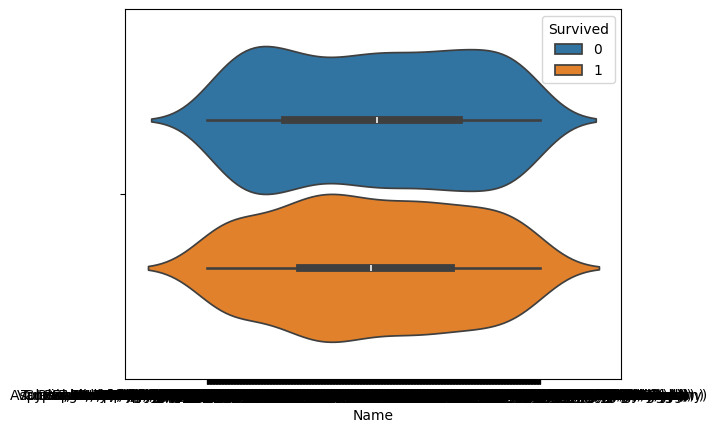

__________________________________________________ 
Sex


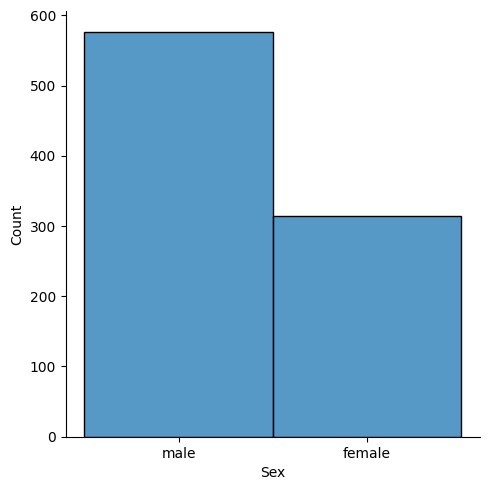

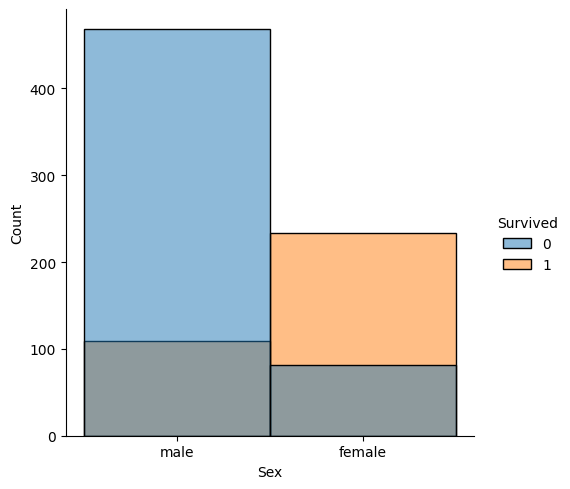

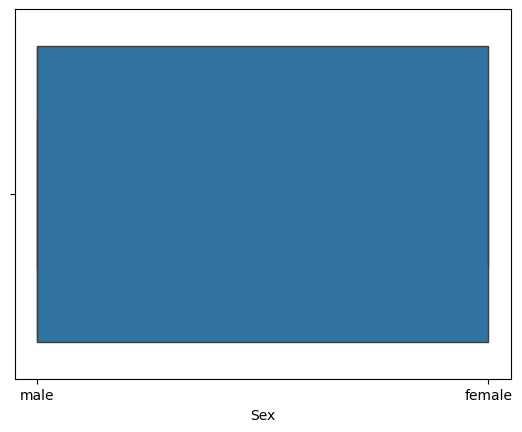

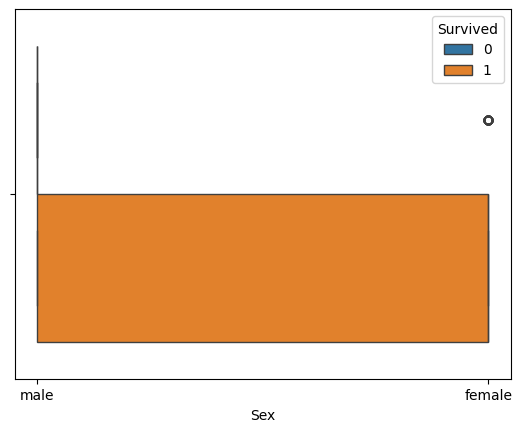

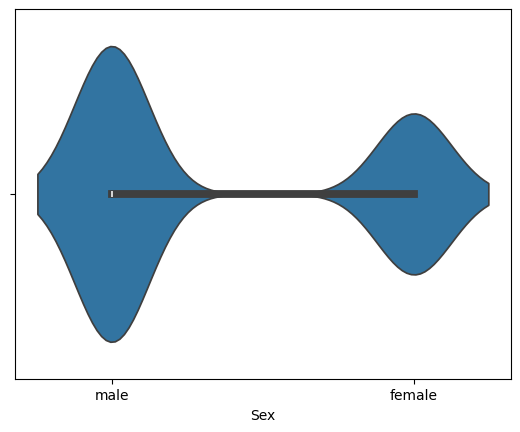

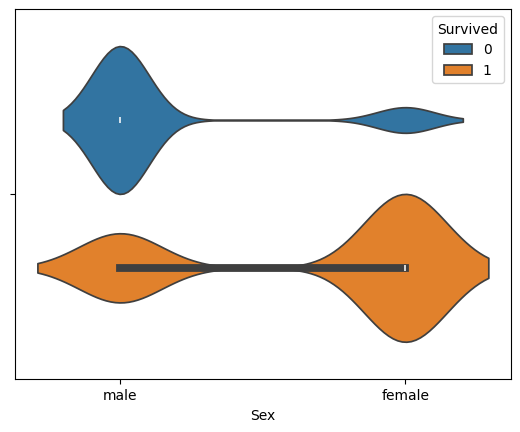

__________________________________________________ 
Age


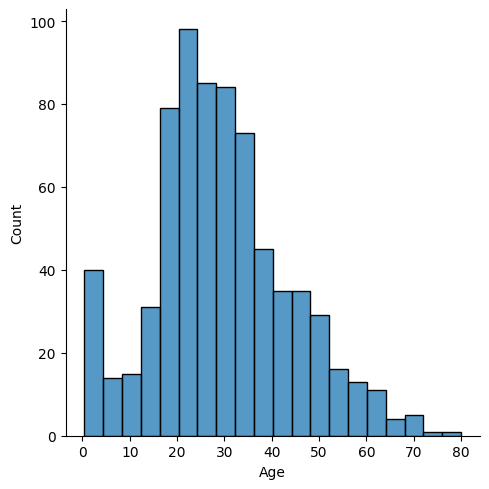

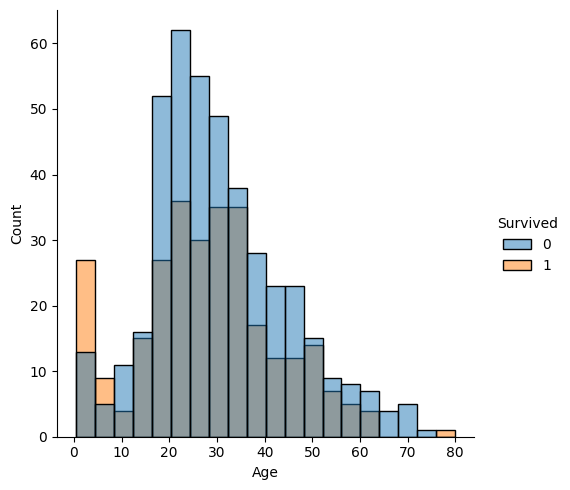

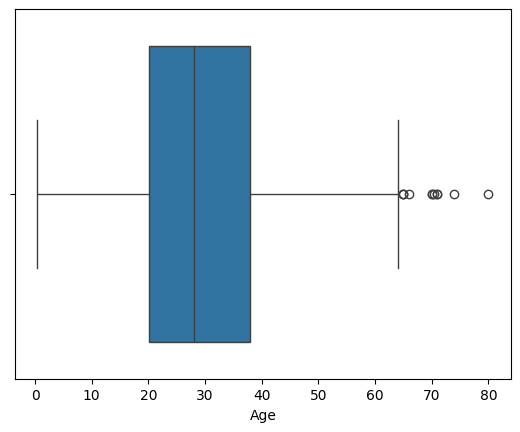

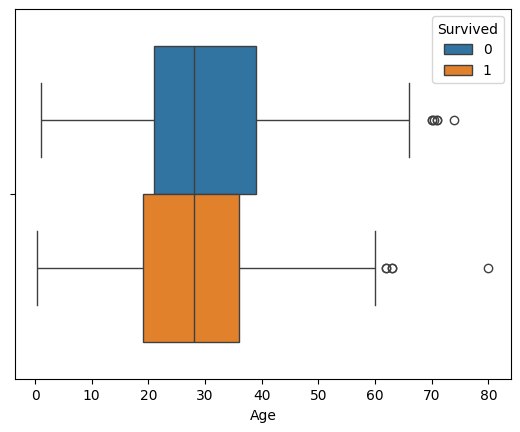

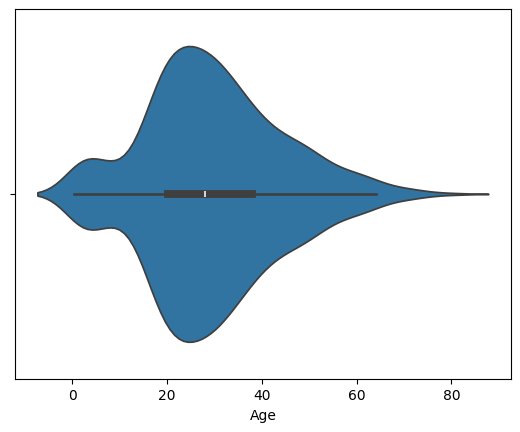

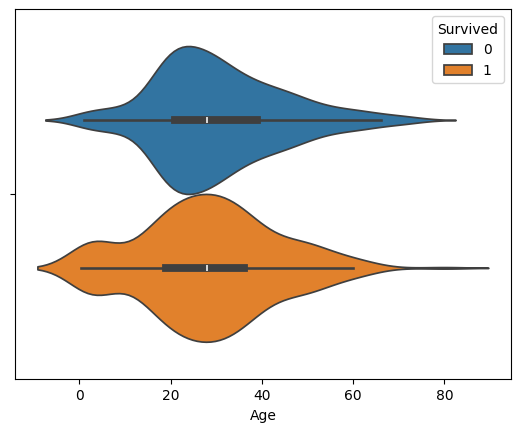

__________________________________________________ 
SibSp


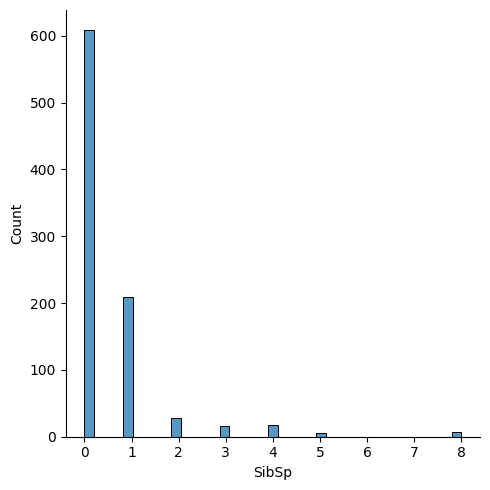

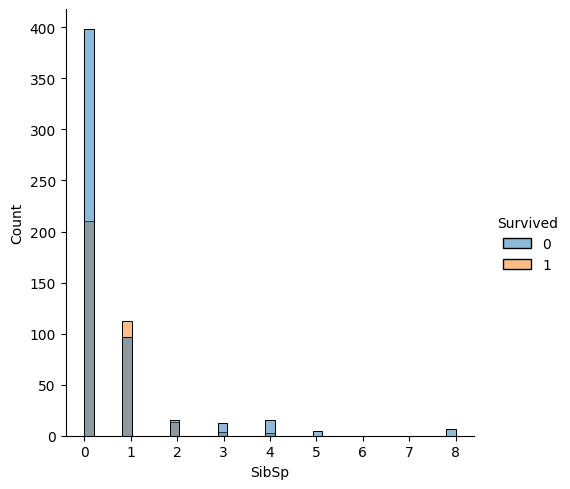

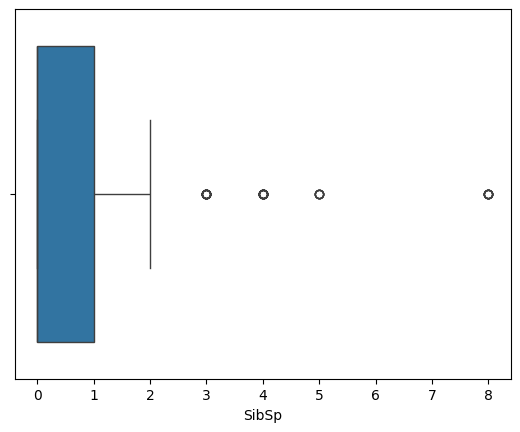

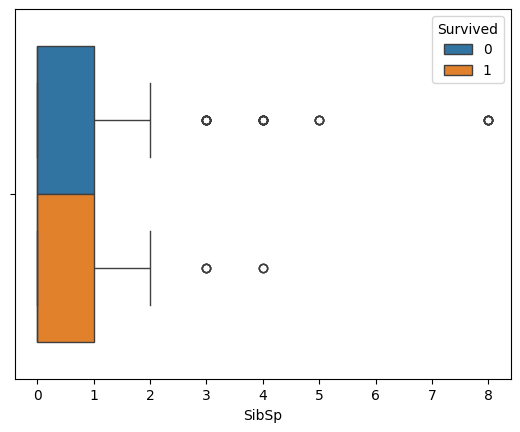

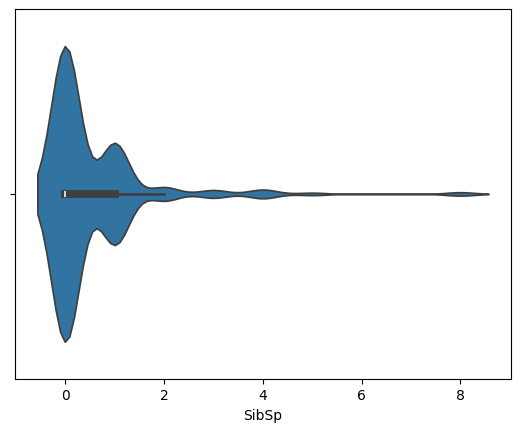

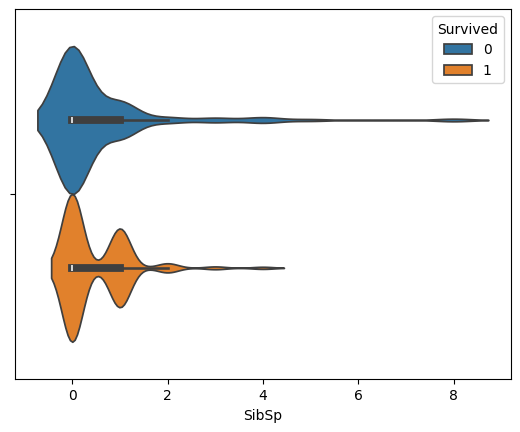

__________________________________________________ 
Parch


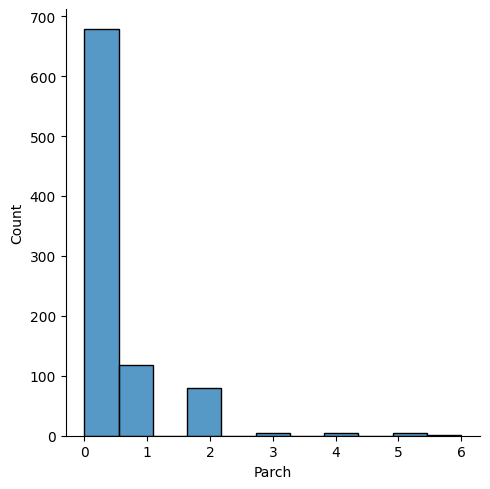

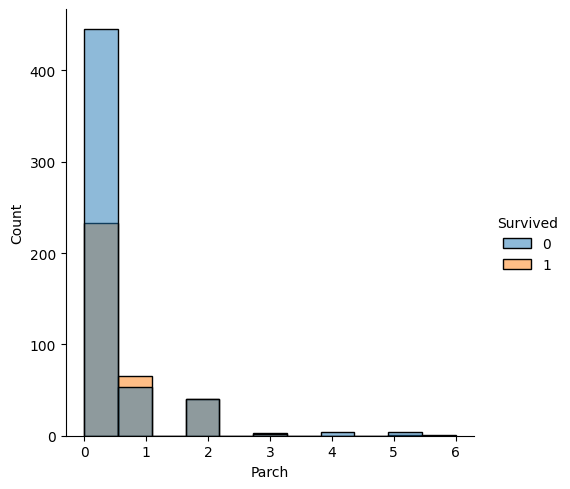

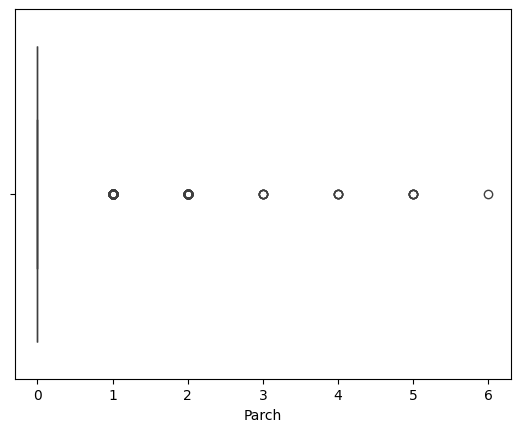

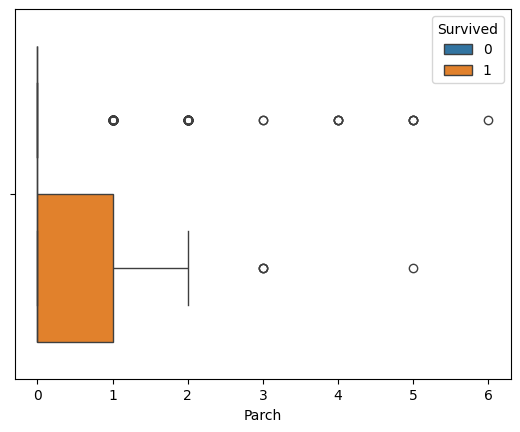

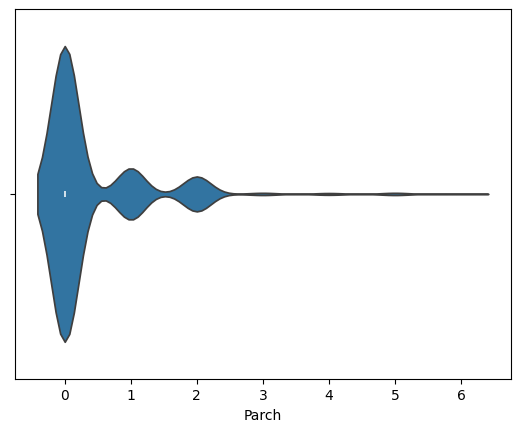

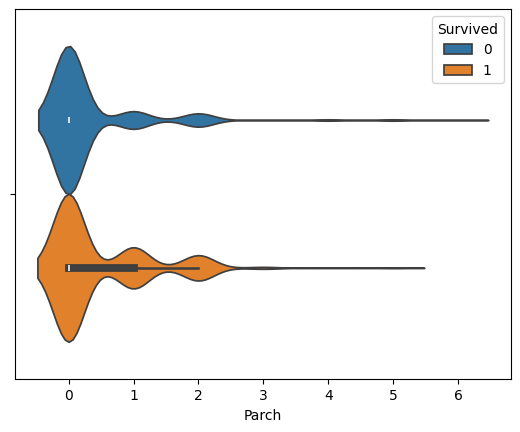

__________________________________________________ 
Ticket


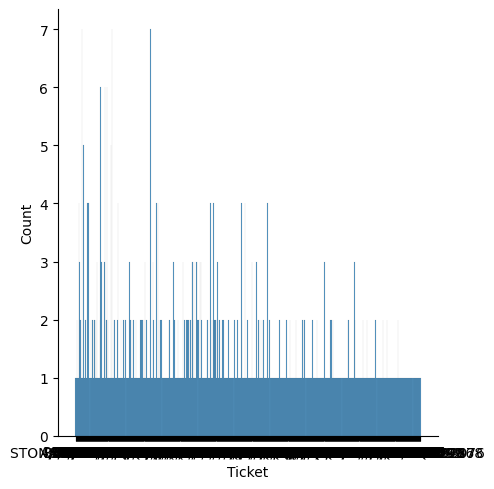

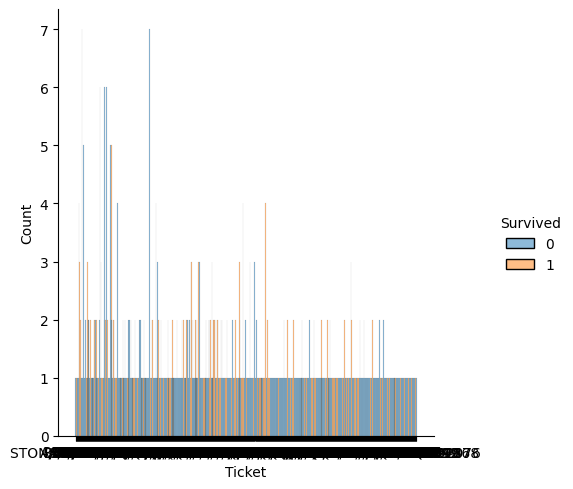

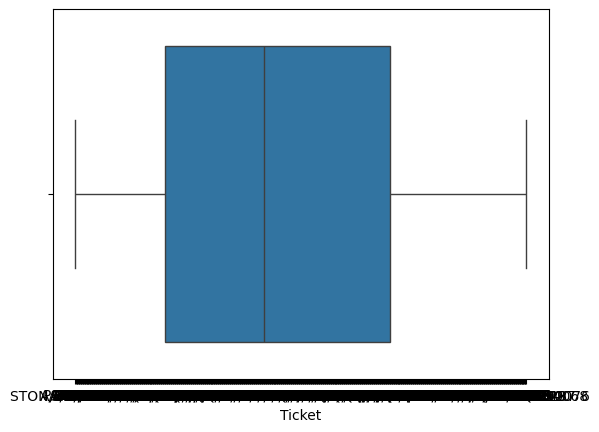

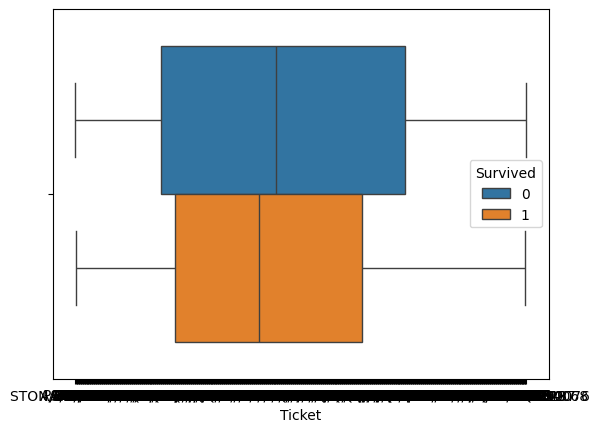

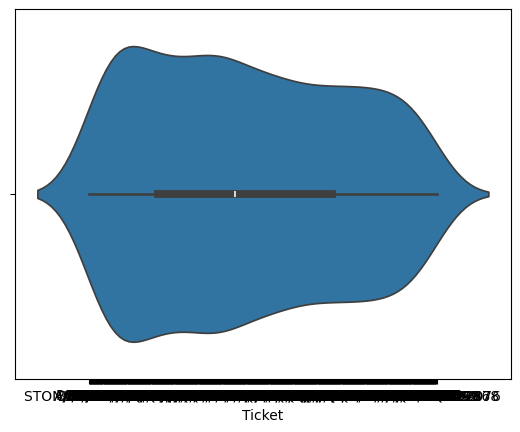

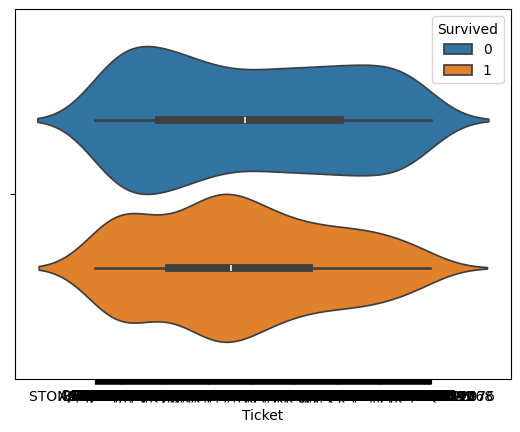

__________________________________________________ 
Fare


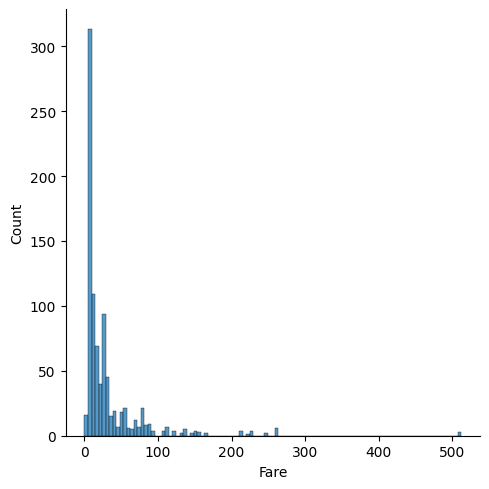

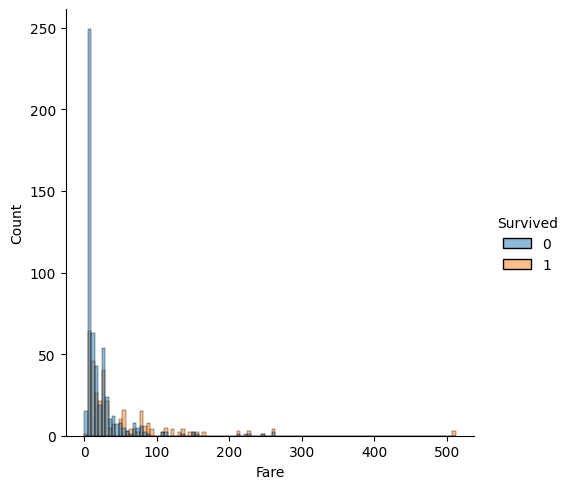

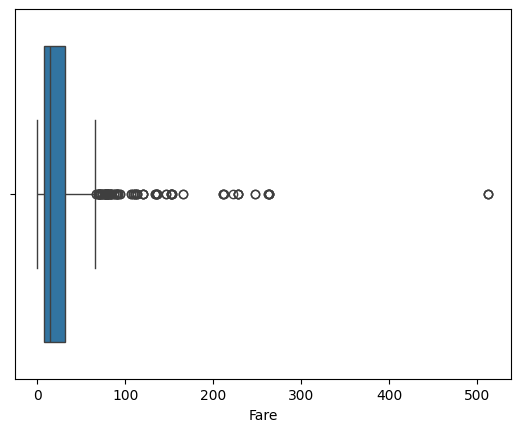

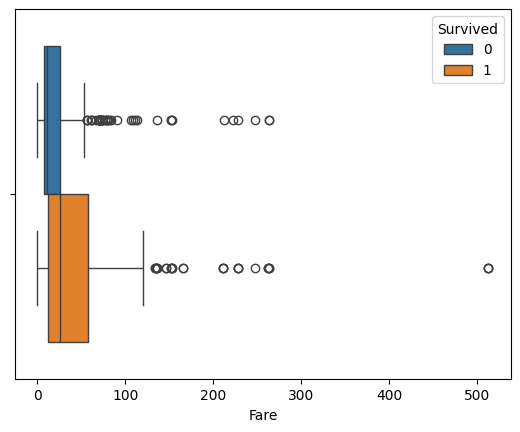

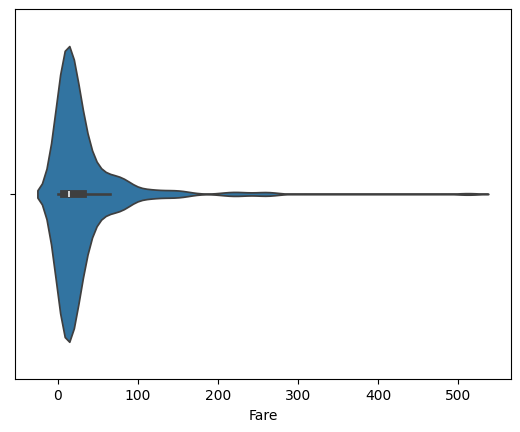

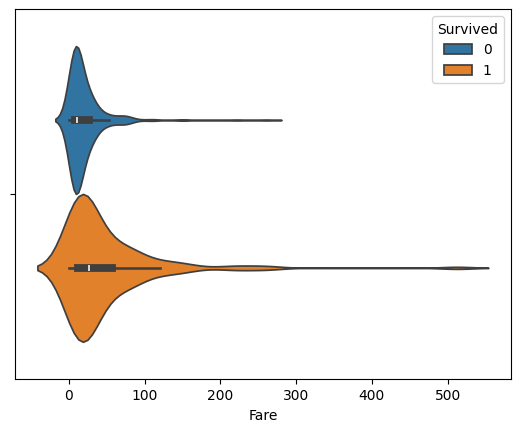

__________________________________________________ 
Cabin


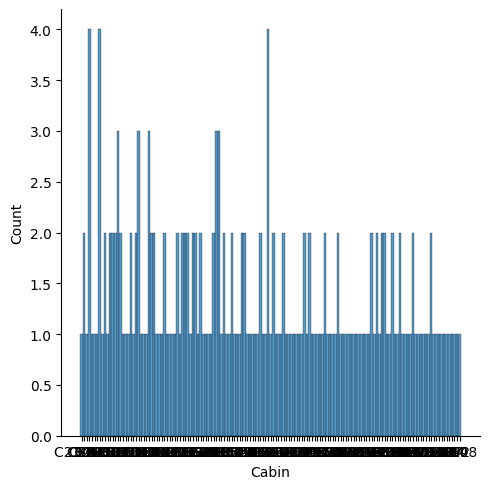

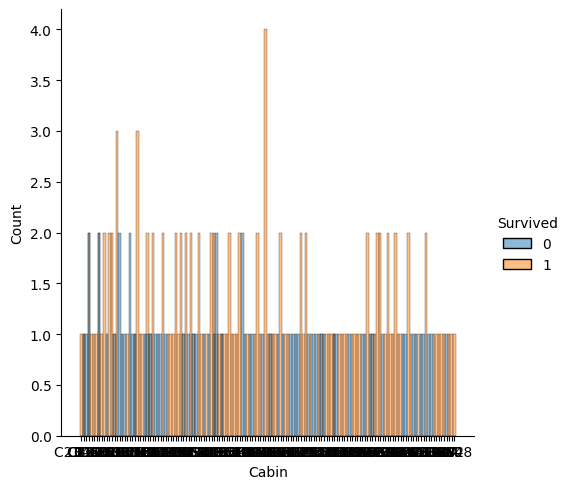

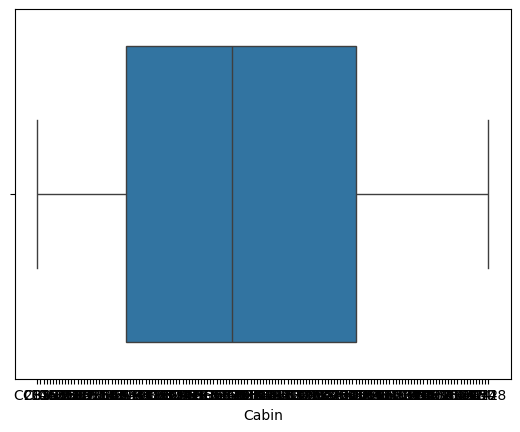

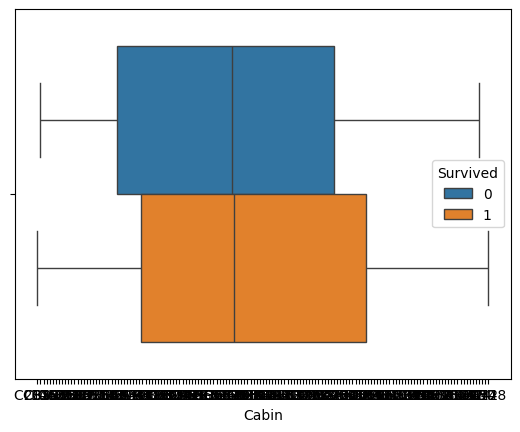

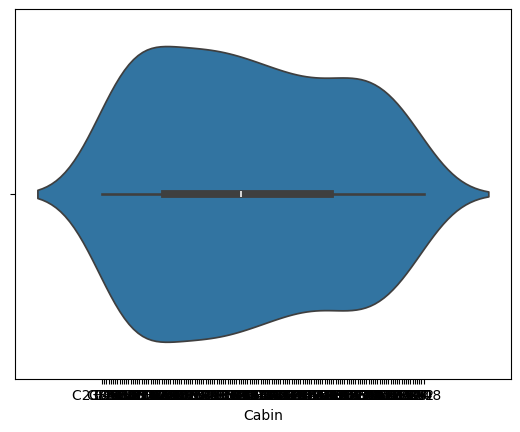

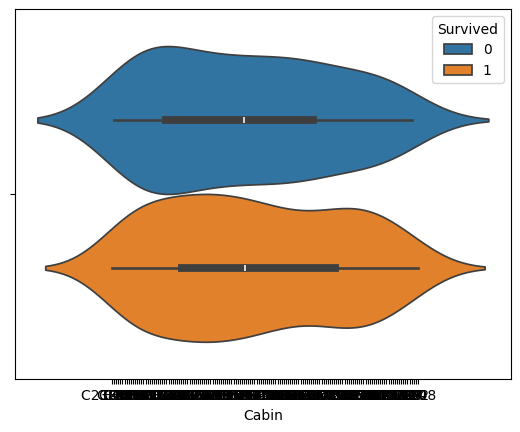

__________________________________________________ 
Embarked


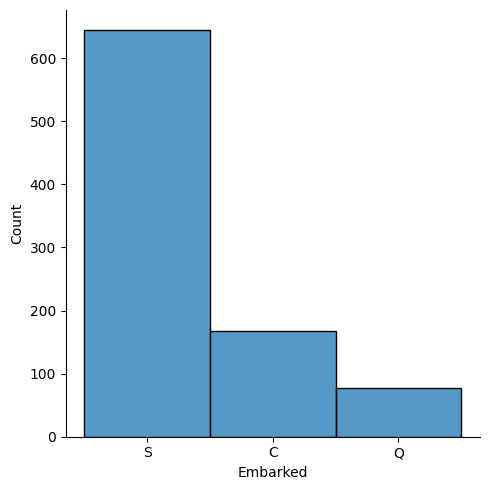

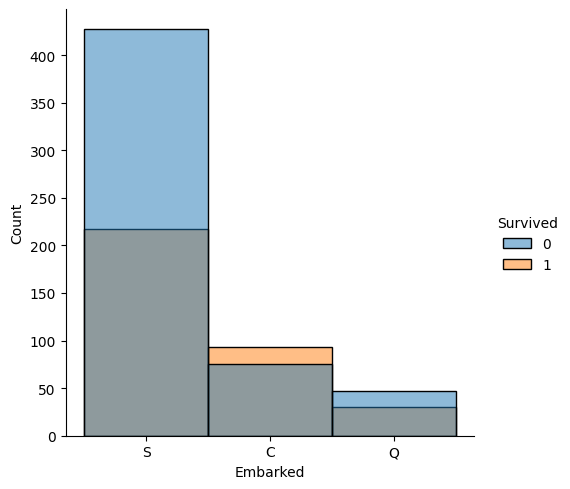

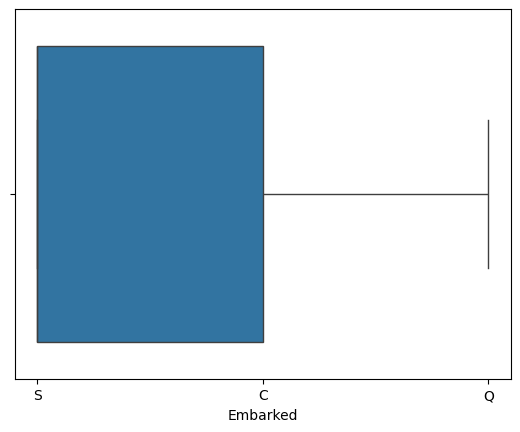

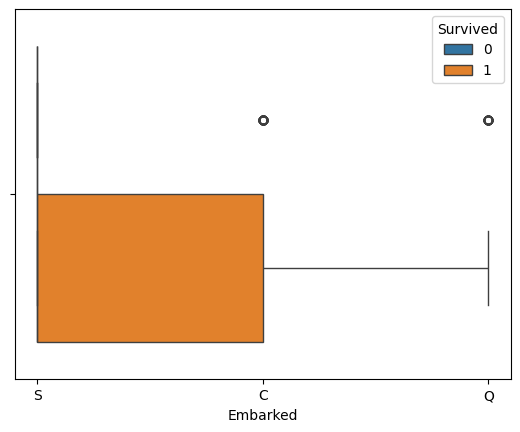

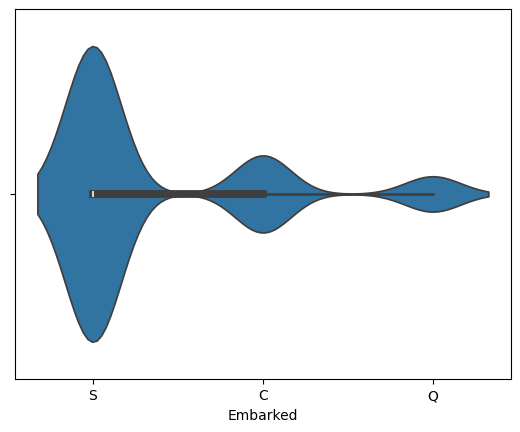

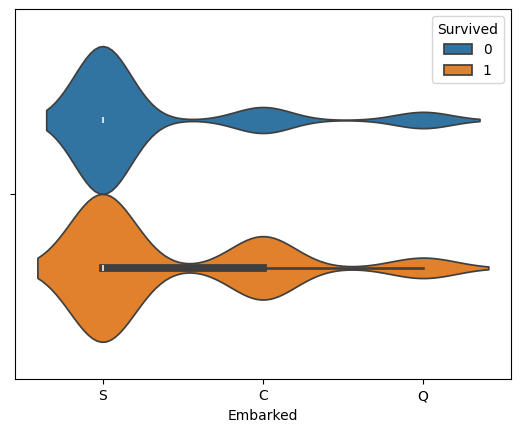

In [7]:
target = 'Survived'
features_EDA_with_Plots(DataSet,target)

# 3. Train Test Split

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    DataSet.drop(target, axis=1), 
    DataSet[target], 
    test_size=0.2, 
    stratify=DataSet[target], 
    random_state=42
)

# 4. Feature Engineering

In [9]:
# def featureEngineering(DataSet1):
#     DataSet = DataSet1.copy()
#     features_to_drop =[]
#     for cols in DataSet1.columns:
#         if (DataSet[cols].dtypes == object) and \
#         (len(DataSet[cols].unique())<=10):
#             print(f'{cols} is object type with low cardinality ({len(DataSet[cols].unique())}), getting dummies for it.')
#             dummies = pd.get_dummies(DataSet[cols], prefix=cols, dtype=int, dummy_na=True)
#             DataSet = pd.concat([DataSet, dummies], axis=1)
#             features_to_drop.append(cols)
#         elif (DataSet[cols].dtypes == object) and \
#         (len(DataSet[cols].unique())>10):
#             print(f'{cols} is object type with high cardinality ({len(DataSet[cols].unique())}), getting first_letter for it & getting dummies for it ')
#             DataSet[f'{cols}_firstLetter'] = DataSet[cols].apply(lambda x: str(x).split()[0][0])
#             dummies = pd.get_dummies(DataSet[f'{cols}_firstLetter'], prefix=f'{cols}_firstLetter', dtype=int, dummy_na=True)
#             DataSet = pd.concat([DataSet, dummies], axis=1)
#             features_to_drop.append(cols)
#             features_to_drop.append(f'{cols}_firstLetter')
#         elif (DataSet[cols].dtype in ['int64', 'float64']) and \
#         (DataSet[cols].nunique() > 20):
#             q=6
#             print(f'{cols} is numeric type with hight cardinality ({DataSet[cols].nunique()}), binning it to {q} bins')
#             DataSet[f'{cols}_bins'] = pd.qcut(DataSet[cols], q=q, labels=False, duplicates='drop')
#             features_to_drop.append(cols)
#         if cols in ['Name']:
#             print(f'{cols} - doing CUSTOM transformation - Creating Title')
#             DataSet[f'{cols}_Title'] = DataSet[cols].apply(lambda x: x.split()[1].replace('.',''))
#             dummies = pd.get_dummies(DataSet[f'{cols}_Title'], prefix=f'{cols}_Title', dtype=int, dummy_na=True)
#             DataSet = pd.concat([DataSet, dummies], axis=1)
#             features_to_drop.append(cols)
#             features_to_drop.append(f'{cols}_Title')
            
            
            
#     print(f'Creating CUSTOM FamilySize features by SibSp + Parch')
#     DataSet['FamilySize'] = DataSet['SibSp'] + DataSet['Parch']
#     print(f'{"-"*50}\nIdentified Object Features that can be dropped : {features_to_drop}')
#     DataSet.drop(columns=features_to_drop,inplace=True)
#     display(DataSet.sample(5))
#     return DataSet
    

In [10]:
# import pandas as pd
# import numpy as np

# def featureEngineering(DataSet1, meta_rules=None):
#     """
#     Generalizes categorization using Integer Encoding instead of OHE.
#     DataSet1: DataFrame to transform
#     meta_rules: If None, 'Fits' rules. If provided, 'Transforms' (Testing mode).
#     """
#     DataSet = DataSet1.copy()
#     features_to_drop = []
#     is_train = meta_rules is None
    
#     if is_train:
#         meta_rules = {
#             'encoding_maps': {}, # Stores {Category: Integer}
#             'bin_edges': {}      # Stores qcut boundaries
#         }

#     for cols in DataSet1.columns:
#         # --- 1. OBJECT HANDLING (Label/Integer Encoding) ---
#         if DataSet[cols].dtypes == object:
#             # A. High Cardinality Logic (First Letter)
#             if DataSet[cols].nunique() > 10:
#                 print(f'{cols}: High Card {DataSet[cols].nunique()} -> Using First Letter Encoding')
#                 val_to_process = DataSet[cols].apply(lambda x: str(x)[0] if pd.notnull(x) else '-')
#                 new_col_name = f'{cols}_FL_encoded'
#             # B. Custom Logic (Name Title)
#             elif cols == 'Name':
#                 print(f'{cols}: Extracting Title and Encoding')
#                 val_to_process = DataSet[cols].str.extract(r' ([A-Za-z]+)\.', expand=False).fillna('Unknown')
#                 new_col_name = f'{cols}_Title_encoded'
#             # C. Low Cardinality Logic (Standard)
#             else:
#                 print(f'{cols}: Low Card -> Integer Encoding')
#                 val_to_process = DataSet[cols].fillna('Missing')
#                 new_col_name = f'{cols}_encoded'

#             # THE ENCODING TRACEABILITY LOGIC
#             if is_train:
#                 unique_vals = val_to_process.unique()
#                 # Create map: {Value: 1, Value2: 2...} Reserve 0 for unknown
#                 meta_rules['encoding_maps'][new_col_name] = {val: i+1 for i, val in enumerate(unique_vals)}
            
#             # Map values. New values in test data that weren't in train become 0
#             DataSet[new_col_name] = val_to_process.map(meta_rules['encoding_maps'][new_col_name]).fillna(0).astype(int)
#             features_to_drop.append(cols)

#         # --- 2. NUMERIC HANDLING (Binning) ---
#         elif (DataSet[cols].dtype in ['int64', 'float64']) and (DataSet[cols].nunique() > 20):
#             q = 6
#             print(f'{cols}: Binning into {q} discrete integers')
#             if is_train:
#                 _, bins = pd.qcut(DataSet[cols], q=q, retbins=True, duplicates='drop')
#                 meta_rules['bin_edges'][cols] = bins
            
#             # Apply bins using saved edges
#             DataSet[f'{cols}_bins'] = pd.cut(DataSet[cols], bins=meta_rules['bin_edges'][cols], 
#                                              labels=False, include_lowest=True)
#             # Handle Nulls/Outliers as a specific category
#             DataSet[f'{cols}_bins'] = DataSet[f'{cols}_bins'].fillna(-1).astype(int)
#             features_to_drop.append(cols)

#     # --- 3. CUSTOM FAMILY SIZE ---
#     if 'SibSp' in DataSet.columns and 'Parch' in DataSet.columns:
#         DataSet['FamilySize'] = DataSet['SibSp'] + DataSet['Parch']
#         print("FamilySize feature created.")

#     # Drop originals
#     existing_drops = [c for c in features_to_drop if c in DataSet.columns]
#     DataSet.drop(columns=existing_drops, inplace=True)
    
#     return DataSet, meta_rules

In [11]:
# import pandas as pd
# import numpy as np
# from sklearn.feature_selection import mutual_info_classif

# def featureEngineering(DataSet1, y=None, meta_rules=None, ohe_threshold=0.05, top_n_interact=3):
#     DataSet = DataSet1.copy()
#     features_to_drop = []
#     is_train = meta_rules is None
    
#     if is_train:
#         if y is None: raise ValueError("y is required for training mode.")
#         meta_rules = {
#             'maps': {'label': {}, 'freq': {}, 'target': {}, 'frequent_cats': {}},
#             'numeric': {'bin_edges': {}, 'global_mean': y.mean()},
#             'top_features': []
#         }

#     # --- 1. PRE-ENCODING: DYNAMIC INTERACTIONS ---
#     # We identify top numeric features to create ratios/products without domain knowledge
#     numeric_cols = DataSet.select_dtypes(include=[np.number]).columns.tolist()
#     if is_train:
#         # Use Mutual Information to find the most "important" numeric features for interactions
#         temp_df = DataSet[numeric_cols].fillna(0)
#         mi_scores = mutual_info_classif(temp_df, y.values.ravel(), random_state=42)
#         meta_rules['top_features'] = [numeric_cols[i] for i in np.argsort(mi_scores)[-top_n_interact:]]
    
#     # Create math-based interactions for top numeric features
#     for i, col_a in enumerate(meta_rules['top_features']):
#         for col_b in meta_rules['top_features'][i+1:]:
#             DataSet[f'{col_a}_{col_b}_ratio'] = DataSet[col_a] / (DataSet[col_b] + 1e-6)
#             DataSet[f'{col_a}_{col_b}_prod'] = DataSet[col_a] * DataSet[col_b]
#             DataSet[f'{col_a}_{col_b}_sum'] = DataSet[col_a] + DataSet[col_b]
#             DataSet[f'{col_a}_{col_b}_diff'] = DataSet[col_a] - DataSet[col_b]

#     # --- 2. THE MAIN PROCESSING LOOP ---
#     for col in DataSet1.columns:
        
#         # A. NUMERIC HANDLING (Log + Binning)
#         if DataSet[col].dtype in ['int64', 'float64']:
#             # Log Transform (Compresses skewness)
#             DataSet[f'{col}_log'] = np.log1p(DataSet[col])
            
#             # Binning (Stable rankings)
#             if is_train:
#                 _, bins = pd.qcut(DataSet[col], q=6, retbins=True, duplicates='drop')
#                 meta_rules['numeric']['bin_edges'][col] = bins
            
#             if col in meta_rules['numeric']['bin_edges']:
#                 DataSet[f'{col}_bins'] = pd.cut(DataSet[col], bins=meta_rules['numeric']['bin_edges'][col], 
#                                                  labels=False, include_lowest=True).fillna(-1).astype(int)
#             features_to_drop.append(col)

#         # B. CATEGORICAL HANDLING (The Quad-Stack)
#         elif DataSet[col].dtypes == object:
#             val_col = DataSet[col].fillna("Missing")

#             # 1. Frequent-Only OHE (Prevents sparsity)
#             if is_train:
#                 counts = val_col.value_counts(normalize=True)
#                 meta_rules['maps']['frequent_cats'][col] = counts[counts >= ohe_threshold].index.tolist()
            
#             frequent_val = val_col.apply(lambda x: x if x in meta_rules['maps']['frequent_cats'][col] else 'Other')
#             ohe_df = pd.get_dummies(frequent_val, prefix=f'{col}_ohe')
#             DataSet = pd.concat([DataSet, ohe_df], axis=1)

#             # 2. Target Encoding (Smoothing applied)
#             if is_train:
#                 m = 10 # Smoothing factor
#                 stats = pd.concat([val_col, y], axis=1).groupby(col).agg(['count', 'mean'])
#                 stats.columns = ['count', 'mean']
#                 smooth = (stats['count'] * stats['mean'] + m * meta_rules['numeric']['global_mean']) / (stats['count'] + m)
#                 meta_rules['maps']['target'][col] = smooth.to_dict()
            
#             DataSet[f'{col}_target'] = val_col.map(meta_rules['maps']['target'].get(col, {})).fillna(meta_rules['numeric']['global_mean'])

#             # 3. Frequency Encoding (Rarity signal)
#             if is_train:
#                 meta_rules['maps']['freq'][col] = val_col.value_counts(normalize=True).to_dict()
#             DataSet[f'{col}_freq'] = val_col.map(meta_rules['maps']['freq'].get(col, {})).fillna(0)

#             # 4. Label Encoding (Unique Identity)
#             if is_train:
#                 unique_vals = val_col.unique()
#                 meta_rules['maps']['label'][col] = {val: i+1 for i, val in enumerate(unique_vals)}
#             DataSet[f'{col}_label'] = val_col.map(meta_rules['maps']['label'].get(col, {})).fillna(0).astype(int)

#             features_to_drop.append(col)

#     # Final cleanup: Drop original columns that were processed
#     DataSet.drop(columns=[c for c in features_to_drop if c in DataSet.columns], inplace=True)
    
#     return DataSet, meta_rules

In [12]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_selection import mutual_info_classif

def featureEngineering(DataSet1, y=None, meta_rules=None, ohe_threshold=0.05, top_n_interact=3, min_word_freq=0.01):
    DataSet = DataSet1.copy()
    features_to_drop = []
    is_train = meta_rules is None
    
    print(f"\n{'='*60}\n🚀 FEATURE MINING ENGINE: {'TRAINING' if is_train else 'TESTING'}\n{'='*60}")

    if is_train:
        if y is None: raise ValueError("y is required for training mode.")
        meta_rules = {
            'maps': {'label': {}, 'freq': {}, 'target': {}, 'frequent_cats': {}},
            'numeric': {'bin_edges': {}, 'global_mean': y.mean()},
            'top_features': [],
            'potential_signals': {} 
        }

    # --- PHASE 1: BLIND TEXT MINING (Your logic + Delimiters) ---
    print(f"🔍 Phase 1: Mining High-Cardinality Strings...")
    obj_cols = DataSet.select_dtypes(include=['object']).columns
    for col in obj_cols:
        if DataSet[col].nunique() > 15:
            print(f"  > Analyzing '{col}'...")
            
            # Blind Signal Miner (Tokenizing)
            if is_train:
                # Strip punctuation and split into words
                words = DataSet[col].str.replace('[^a-zA-Z]', ' ', regex=True).str.split(expand=True).stack()
                counts = words.value_counts(normalize=True)
                # Store words that meet frequency threshold
                meta_rules['potential_signals'][col] = counts[counts >= min_word_freq].index.tolist()
                print(f"    * Signals found: {meta_rules['potential_signals'][col][:5]}...")

            # Create binary flags for signal words
            for word in meta_rules['potential_signals'].get(col, []):
                if len(word) > 1:
                    DataSet[f'{col}_{word}_flag'] = DataSet[col].str.contains(word, case=False, na=False).astype(int)
            
            # Structural mining
            DataSet[f'{col}_initial'] = DataSet[col].astype(str).str[0].str.upper()
            DataSet[f'{col}_len'] = DataSet[col].astype(str).apply(len)
            
            # Delimiter Extraction (Title Guessing)
            if DataSet[col].astype(str).str.contains(',').any():
                DataSet[f'{col}_extracted'] = DataSet[col].astype(str).str.split(',').str[1].str.split('.').str[0].str.strip()
            
            features_to_drop.append(col)

    # --- PHASE 2: DYNAMIC NUMERIC INTERACTIONS ---
    print(f"🔢 Phase 2: Generating Numeric Interactions (Sums/Ratios)...")
    numeric_cols = DataSet.select_dtypes(include=[np.number]).columns.tolist()
    if is_train:
        temp_df = DataSet[numeric_cols].fillna(0)
        mi_scores = mutual_info_classif(temp_df, y.values.ravel(), random_state=42)
        meta_rules['top_features'] = [numeric_cols[i] for i in np.argsort(mi_scores)[-top_n_interact:]]
        print(f"  > Interactions generated for: {meta_rules['top_features']}")
    
    for i, col_a in enumerate(meta_rules['top_features']):
        for col_b in meta_rules['top_features'][i+1:]:
            DataSet[f'{col_a}_{col_b}_sum'] = DataSet[col_a] + DataSet[col_b]
            DataSet[f'{col_a}_{col_b}_ratio'] = DataSet[col_a] / (DataSet[col_b] + 1e-6)

    # --- PHASE 3: THE QUAD-STACK + SCALING ---
    print(f"🛠️ Phase 3: Applying Scaling & Quad-Stack Encoders...")
    for col in [c for c in DataSet.columns if c not in features_to_drop]:
        
        # Branch A: Numeric (Handles Skewness and -1)
        if DataSet[col].dtype in ['int64', 'float64'] and not col.endswith('_flag'):
            # Detect -1 missing values
            if (DataSet[col] == -1).any():
                DataSet[f'{col}_was_missing'] = (DataSet[col] == -1).astype(int)

            # Log Transform (Clip at 0 to avoid -inf from -1 values)
            DataSet[f'{col}_log'] = np.log1p(DataSet[col].clip(lower=0))
            
            # Binning
            if is_train:
                _, bins = pd.qcut(DataSet[col], q=6, retbins=True, duplicates='drop')
                meta_rules['numeric']['bin_edges'][col] = bins
            if col in meta_rules['numeric']['bin_edges']:
                DataSet[f'{col}_bins'] = pd.cut(DataSet[col], bins=meta_rules['numeric']['bin_edges'][col], 
                                                 labels=False, include_lowest=True).fillna(-1).astype(int)
            features_to_drop.append(col)

        # Branch B: Categorical (The Quad-Stack)
        elif DataSet[col].dtypes == object or col.endswith('_initial') or col.endswith('_extracted'):
            val_col = DataSet[col].fillna("Missing")
            if is_train:
                # Target, Freq, Label, and OHE map building
                stats = pd.concat([val_col, y], axis=1).groupby(col).agg(['count', 'mean'])
                stats.columns = ['count', 'mean']
                m = 10
                meta_rules['maps']['target'][col] = ((stats['count'] * stats['mean'] + m * meta_rules['numeric']['global_mean']) / (stats['count'] + m)).to_dict()
                meta_rules['maps']['freq'][col] = val_col.value_counts(normalize=True).to_dict()
                meta_rules['maps']['label'][col] = {v: i+1 for i, v in enumerate(val_col.unique())}
                meta_rules['maps']['frequent_cats'][col] = val_col.value_counts(normalize=True)[lambda x: x >= ohe_threshold].index.tolist()

            # Execute Encoders
            ohe_df = pd.get_dummies(val_col.apply(lambda x: x if x in meta_rules['maps']['frequent_cats'][col] else 'Other'), prefix=f'{col}_ohe')
            DataSet = pd.concat([DataSet, ohe_df], axis=1)
            DataSet[f'{col}_target'] = val_col.map(meta_rules['maps']['target'].get(col, {})).fillna(meta_rules['numeric']['global_mean'])
            DataSet[f'{col}_freq'] = val_col.map(meta_rules['maps']['freq'].get(col, {})).fillna(0)
            DataSet[f'{col}_label'] = val_col.map(meta_rules['maps']['label'].get(col, {})).fillna(0).astype(int)
            features_to_drop.append(col)

    DataSet.drop(columns=[c for c in features_to_drop if c in DataSet.columns], inplace=True)
    print(f"{'='*60}\n✅ COMPLETE: {DataSet.shape[1]} Features Created\n{'='*60}")
    return DataSet, meta_rules

In [13]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_selection import mutual_info_classif

def featureEngineering(DataSet1, y=None, meta_rules=None, ohe_threshold=0.05, top_n_interact=3, min_word_freq=0.01):
    DataSet = DataSet1.copy()
    features_to_drop = []
    is_train = meta_rules is None
    
    print(f"\n{'='*60}\n🚀 ENGINE START: {'TRAINING' if is_train else 'TESTING'}\n{'='*60}")

    if is_train:
        if y is None: raise ValueError("y is required for training mode.")
        meta_rules = {
            'maps': {'label': {}, 'freq': {}, 'target': {}, 'frequent_cats': {}},
            'numeric': {'bin_edges': {}, 'global_mean': y.mean()},
            'top_features': [],
            'potential_signals': {} 
        }

    # --- PHASE 1: BLIND TEXT MINING ---
    print(f"🔍 Phase 1: Mining High-Cardinality Strings...")
    obj_cols = DataSet.select_dtypes(include=['object']).columns
    for col in obj_cols:
        if DataSet[col].nunique() > 15:
            print(f"  > Analyzing '{col}'...")
            
            if is_train:
                # Token Mining Logic
                words = DataSet[col].str.replace('[^a-zA-Z]', ' ', regex=True).str.split(expand=True).stack()
                counts = words.value_counts(normalize=True)
                meta_rules['potential_signals'][col] = counts[counts >= min_word_freq].index.tolist()
                print(f"    * Signals found: {meta_rules['potential_signals'][col][:5]}...")

            for word in meta_rules['potential_signals'].get(col, []):
                if len(word) > 1:
                    # Creating the FLAG
                    DataSet[f'{col}_{word}_flag'] = DataSet[col].str.contains(word, case=False, na=False).astype(int)
            
            # Creating Structural Features
            DataSet[f'{col}_initial'] = DataSet[col].astype(str).str[0].str.upper()
            DataSet[f'{col}_len'] = DataSet[col].astype(str).apply(len)
            
            if DataSet[col].astype(str).str.contains(',').any():
                DataSet[f'{col}_extracted'] = DataSet[col].astype(str).str.split(',').str[1].str.split('.').str[0].str.strip()
            
            features_to_drop.append(col)

    # --- PHASE 2: NUMERIC INTERACTIONS ---
    print(f"🔢 Phase 2: Generating Numeric Interactions...")
    numeric_cols = DataSet.select_dtypes(include=[np.number]).columns.tolist()
    if is_train:
        temp_df = DataSet[numeric_cols].fillna(0)
        mi_scores = mutual_info_classif(temp_df, y.values.ravel(), random_state=42)
        meta_rules['top_features'] = [numeric_cols[i] for i in np.argsort(mi_scores)[-top_n_interact:]]
    
    for i, col_a in enumerate(meta_rules['top_features']):
        for col_b in meta_rules['top_features'][i+1:]:
            DataSet[f'{col_a}_{col_b}_sum'] = DataSet[col_a] + DataSet[col_b]
            DataSet[f'{col_a}_{col_b}_ratio'] = DataSet[col_a] / (DataSet[col_b] + 1e-6)

    # --- PHASE 3: THE QUAD-STACK LOOP (Refreshed column list) ---
    print(f"🛠️ Phase 3: Applying Quad-Stack Encoders...")
    
    # We take a snapshot of columns NOW, including all the new mined ones
    current_cols = [c for c in DataSet.columns if c not in features_to_drop]
    
    for col in current_cols:
        # A: Numeric handling (Log + Binning)
        if DataSet[col].dtype in ['int64', 'float64'] and not col.endswith('_flag'):
            if (DataSet[col] == -1).any():
                DataSet[f'{col}_was_missing'] = (DataSet[col] == -1).astype(int)

            DataSet[f'{col}_log'] = np.log1p(DataSet[col].clip(lower=0))
            
            if is_train:
                _, bins = pd.qcut(DataSet[col], q=6, retbins=True, duplicates='drop')
                meta_rules['numeric']['bin_edges'][col] = bins
            if col in meta_rules['numeric']['bin_edges']:
                DataSet[f'{col}_bins'] = pd.cut(DataSet[col], bins=meta_rules['numeric']['bin_edges'][col], 
                                                 labels=False, include_lowest=True).fillna(-1).astype(int)
            features_to_drop.append(col)

        # B: Categorical handling (OHE, Target, Freq, Label)
        elif DataSet[col].dtypes == object or col.endswith('_initial') or col.endswith('_extracted'):
            val_col = DataSet[col].fillna("Missing")
            if is_train:
                stats = pd.concat([val_col, y], axis=1).groupby(col).agg(['count', 'mean'])
                stats.columns = ['count', 'mean']
                m = 10
                meta_rules['maps']['target'][col] = ((stats['count'] * stats['mean'] + m * meta_rules['numeric']['global_mean']) / (stats['count'] + m)).to_dict()
                meta_rules['maps']['freq'][col] = val_col.value_counts(normalize=True).to_dict()
                meta_rules['maps']['label'][col] = {v: i+1 for i, v in enumerate(val_col.unique())}
                meta_rules['maps']['frequent_cats'][col] = val_col.value_counts(normalize=True)[lambda x: x >= ohe_threshold].index.tolist()

            ohe_df = pd.get_dummies(val_col.apply(lambda x: x if x in meta_rules['maps']['frequent_cats'][col] else 'Other'), prefix=f'{col}_ohe')
            DataSet = pd.concat([DataSet, ohe_df], axis=1)
            DataSet[f'{col}_target'] = val_col.map(meta_rules['maps']['target'].get(col, {})).fillna(meta_rules['numeric']['global_mean'])
            DataSet[f'{col}_freq'] = val_col.map(meta_rules['maps']['freq'].get(col, {})).fillna(0)
            DataSet[f'{col}_label'] = val_col.map(meta_rules['maps']['label'].get(col, {})).fillna(0).astype(int)
            features_to_drop.append(col)

    # --- FINAL CLEANUP FOR YOUR SELECTOR ---
    DataSet.drop(columns=[c for c in features_to_drop if c in DataSet.columns], inplace=True)
    
    # Ensure all Booleans (from OHE or flags) are integers
    bool_cols = DataSet.select_dtypes(include=['bool']).columns
    DataSet[bool_cols] = DataSet[bool_cols].astype(int)
    
    # Final check for Infinity and NaNs
    DataSet = DataSet.replace([np.inf, -np.inf], np.nan).fillna(0)

    print(f"{'='*60}\n✅ COMPLETE: {DataSet.shape[1]} Features Created\n{'='*60}")
    return DataSet, meta_rules

In [14]:
# EngineeredDataSet = featureEngineering(DataSet)
EngineeredDataSet, Train_rules = featureEngineering(X_train,y_train)


🚀 ENGINE START: TRAINING
🔍 Phase 1: Mining High-Cardinality Strings...
  > Analyzing 'Name'...
    * Signals found: ['Mr', 'Miss', 'Mrs', 'William', 'John']...
  > Analyzing 'Ticket'...
    * Signals found: ['PC', 'C', 'A', 'O', 'STON']...
  > Analyzing 'Cabin'...
    * Signals found: ['B', 'C', 'E', 'D', 'A']...
🔢 Phase 2: Generating Numeric Interactions...
🛠️ Phase 3: Applying Quad-Stack Encoders...
✅ COMPLETE: 95 Features Created


In [15]:
EngineeredDataSet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 95 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name_Mr_flag                712 non-null    int64  
 1   Name_Miss_flag              712 non-null    int64  
 2   Name_Mrs_flag               712 non-null    int64  
 3   Name_William_flag           712 non-null    int64  
 4   Name_John_flag              712 non-null    int64  
 5   Name_Master_flag            712 non-null    int64  
 6   Ticket_PC_flag              712 non-null    int64  
 7   Ticket_STON_flag            712 non-null    int64  
 8   Ticket_SOTON_flag           712 non-null    int64  
 9   Ticket_SC_flag              712 non-null    int64  
 10  Ticket_CA_flag              712 non-null    int64  
 11  Ticket_PARIS_flag           712 non-null    int64  
 12  Ticket_PP_flag              712 non-null    int64  
 13  Ticket_OQ_flag              712 non-nu

In [16]:
EngineeredDataSet.nunique()

Name_Mr_flag                  2
Name_Miss_flag                2
Name_Mrs_flag                 2
Name_William_flag             2
Name_John_flag                2
                           ... 
Pclass_Fare_ratio_bins        6
Name_len_Fare_sum_log       528
Name_len_Fare_sum_bins        6
Name_len_Fare_ratio_log     590
Name_len_Fare_ratio_bins      6
Length: 95, dtype: int64

In [17]:
# EngineeredDataSet.drop(columns=['Name_FL_encoded','PassengerId_bins'],inplace=True, axis=1)

In [18]:
EngineeredDataSet.columns

Index(['Name_Mr_flag', 'Name_Miss_flag', 'Name_Mrs_flag', 'Name_William_flag',
       'Name_John_flag', 'Name_Master_flag', 'Ticket_PC_flag',
       'Ticket_STON_flag', 'Ticket_SOTON_flag', 'Ticket_SC_flag',
       'Ticket_CA_flag', 'Ticket_PARIS_flag', 'Ticket_PP_flag',
       'Ticket_OQ_flag', 'Ticket_Paris_flag', 'Ticket_LINE_flag',
       'PassengerId_log', 'PassengerId_bins', 'Pclass_log', 'Pclass_bins',
       'Sex_ohe_female', 'Sex_ohe_male', 'Sex_target', 'Sex_freq', 'Sex_label',
       'Age_log', 'Age_bins', 'SibSp_log', 'SibSp_bins', 'Parch_log',
       'Parch_bins', 'Fare_log', 'Fare_bins', 'Embarked_ohe_C',
       'Embarked_ohe_Other', 'Embarked_ohe_Q', 'Embarked_ohe_S',
       'Embarked_target', 'Embarked_freq', 'Embarked_label',
       'Name_initial_ohe_A', 'Name_initial_ohe_B', 'Name_initial_ohe_C',
       'Name_initial_ohe_D', 'Name_initial_ohe_H', 'Name_initial_ohe_L',
       'Name_initial_ohe_M', 'Name_initial_ohe_Other', 'Name_initial_ohe_P',
       'Name_initial_ohe

In [19]:
EngineeredDataSet

,Name_Mr_flag,Name_Miss_flag,Name_Mrs_flag,Name_William_flag,Name_John_flag,Name_Master_flag,Ticket_PC_flag,Ticket_STON_flag,Ticket_SOTON_flag,Ticket_SC_flag,...,Pclass_Name_len_ratio_log,Pclass_Name_len_ratio_bins,Pclass_Fare_sum_log,Pclass_Fare_sum_bins,Pclass_Fare_ratio_log,Pclass_Fare_ratio_bins,Name_len_Fare_sum_log,Name_len_Fare_sum_bins,Name_len_Fare_ratio_log,Name_len_Fare_ratio_bins
692,1,0,0,0,0,0,0,0,0,0,...,0.223144,5,4.102574,5,0.051739,1,4.241266,4,0.192606,0
481,1,0,0,0,0,0,0,0,0,0,...,0.060625,1,1.098612,0,14.508658,5,3.496508,1,17.281246,5
527,1,0,0,0,1,0,1,0,0,0,...,0.054067,1,5.410660,5,0.004499,0,5.483880,5,0.078036,0
855,1,0,1,0,0,0,0,0,0,0,...,0.109199,3,2.591516,2,0.278280,3,3.593194,2,1.329922,4
801,1,0,1,0,0,0,0,0,0,0,...,0.045462,1,3.375880,4,0.073427,1,4.252060,4,0.970057,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,0,1,0,0,0,0,0,0,0,0,...,0.087011,2,2.474789,1,0.322626,4,3.734789,2,1.646395,5
258,0,1,0,0,0,0,1,0,0,0,...,0.060625,1,6.242864,5,0.001950,0,6.271611,5,0.030752,0
736,1,0,1,0,0,0,0,0,0,0,...,0.074108,2,3.647406,4,0.083672,2,4.309120,4,0.758254,2
462,1,0,0,0,0,0,0,0,0,0,...,0.057158,1,3.701302,4,0.025642,1,4.034241,4,0.365725,0


#  - Features Dropping

In [20]:
EngineeredDataSet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 95 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name_Mr_flag                712 non-null    int64  
 1   Name_Miss_flag              712 non-null    int64  
 2   Name_Mrs_flag               712 non-null    int64  
 3   Name_William_flag           712 non-null    int64  
 4   Name_John_flag              712 non-null    int64  
 5   Name_Master_flag            712 non-null    int64  
 6   Ticket_PC_flag              712 non-null    int64  
 7   Ticket_STON_flag            712 non-null    int64  
 8   Ticket_SOTON_flag           712 non-null    int64  
 9   Ticket_SC_flag              712 non-null    int64  
 10  Ticket_CA_flag              712 non-null    int64  
 11  Ticket_PARIS_flag           712 non-null    int64  
 12  Ticket_PP_flag              712 non-null    int64  
 13  Ticket_OQ_flag              712 non-nu

In [21]:
# def feature_drop_cleaning(DataSet, target, corr_thres=0.85, leak_thres=0.97,missing_thres=0.50):
#     df_clean = DataSet.copy()
#     df_clean.drop_duplicates(inplace=True)
#     for col in DataSet.drop(columns=[target]).columns:
#         # print(f'{'-'*10}\nProcessing {col}')
#         # print(DataSet[col])
#         if df_clean[col].isnull().mean()>missing_thres:
#             print(f'Dropping {col} since it has high missing perc.')
#             df_clean.drop(columns=[col],inplace=True)
#         elif df_clean[col].nunique()<=1:
#             print(f'Dropping {col} since it has one or less value in entire col.')
#             df_clean.drop(columns=[col],inplace=True)
#         elif (df_clean[col].dtype in ['object', 'int64']) and \
#             ('id' in col.lower()) and \
#             (df_clean[col].nunique()/len(df_clean) > 0.98):
#             print(f'Dropping {col} since it is suspected to be ID col')
#             df_clean.drop(columns=[col],inplace=True)
#         elif (df_clean[col].dtype.type in [np.number]) and (df_clean[col].corr(df_clean[target]) > leak_thres):
#             print(f'Dropping {col} since it is suspected to be target leaker')
#             df_clean.drop(cols=[col],inplace=True)
#     corr_matrix = df_clean.corr().abs()
#     upprTriMat = np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
#     corr_matrix_upTri = corr_matrix.where(upprTriMat)
#     display(corr_matrix_upTri)
#     corrfeat_to_drop = [cols for cols in corr_matrix_upTri.columns if any(corr_matrix_upTri[cols]>corr_thres)]
#     print(f'Potential Drop: {corrfeat_to_drop} since they are correlated with other feature')
#     # df_clean.drop(columns=corrfeat_to_drop,inplace=True)
#     return df_clean
    
            
            

In [22]:
# cleanedDataSet = feature_drop_cleaning(EngineeredDataSet,target)

In [23]:
# missingImputation(cleanedDataSet,'-99999.1111')

In [24]:
# cleanedDataSet.shape

In [25]:
# cleanedDataSet.info()

# 5. Features Selection 

In [26]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import ShuffleSplit
# from sklearn.preprocessing import StandardScaler
# from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
# from sklearn.linear_model import Lasso, LogisticRegression
# from xgboost import XGBRegressor, XGBClassifier

# def feature_selection_function(df, target_col, task='regression', n_iterations=10, top_k=10):
#     X = df.drop(columns=[target_col])
#     y = df[target_col]

#     feature_votes = pd.Series(0, index=X.columns)

#     scaler = StandardScaler()
#     X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

#     ss = ShuffleSplit(n_splits=n_iterations, test_size=0.2, random_state=42)

#     for i, (train_idx, _) in enumerate(ss.split(X_scaled)):
#         X_sub, y_sub = X_scaled.iloc[train_idx], y.iloc[train_idx]

#         mi_func = mutual_info_regression if task == 'regression' else mutual_info_classif
#         mi_scores = mi_func(X_sub, y_sub)
#         mi_rank = pd.Series(mi_scores, index=X.columns).rank()

#         xgb = XGBRegressor(n_jobs=-1) if task == 'regression' else XGBClassifier(n_jobs=-1)
#         xgb.fit(X_sub, y_sub)
#         xgb_rank = pd.Series(xgb.feature_importances_, index=X.columns).rank()

#         if task == 'regression':
#             lin_mod = Lasso(alpha=0.01) 
#         else:
#             lin_mod = LogisticRegression(penalty='l1', solver='liblinear')
        
#         lin_mod.fit(X_sub, y_sub)
#         lin_scores = np.abs(lin_mod.coef_.flatten())
#         lin_rank = pd.Series(lin_scores, index=X.columns).rank()


#         iteration_rank = (mi_rank + xgb_rank + lin_rank) / 3
#         iteration_winners = iteration_rank.nlargest(top_k).index
        

#         feature_votes[iteration_winners] += 1
#         print(f"   Done: {i+1}/{n_iterations}")

#     threshold = n_iterations * 0.7
#     stable_features = feature_votes[feature_votes >= threshold].index.tolist()
#     return df[stable_features + [target_col]], stable_features

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.linear_model import Lasso, LogisticRegression
from xgboost import XGBRegressor, XGBClassifier

def feature_selection_function(X_df, y_series, task='regression', n_iterations=10, top_k=20):
    # --- 1. PRE-FLIGHT CLEANUP ---
    # Ensure no booleans, infs, or nans reach the models
    X = X_df.copy()
    X = X.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    y = y_series.copy()

    print(f"\n{'='*60}\n🗳️ FEATURE VOTING ENGINE STARTING (k={top_k})\n{'='*60}")
    
    feature_votes = pd.Series(0, index=X.columns)

    # Scaling is mandatory for Lasso/Logistic Regression coefficients to be comparable
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    ss = ShuffleSplit(n_splits=n_iterations, test_size=0.2, random_state=42)

    # --- 2. THE VOTING LOOP ---
    for i, (train_idx, _) in enumerate(ss.split(X_scaled)):
        X_sub, y_sub = X_scaled.iloc[train_idx], y.iloc[train_idx]

        # A. Information Theory Rank (Mutual Info)
        mi_func = mutual_info_regression if task == 'regression' else mutual_info_classif
        mi_scores = mi_func(X_sub, y_sub)
        mi_rank = pd.Series(mi_scores, index=X.columns).rank()

        # B. Gradient Boosting Rank (XGBoost)
        xgb = XGBRegressor(n_jobs=-1, random_state=42) if task == 'regression' else XGBClassifier(n_jobs=-1, random_state=42)
        xgb.fit(X_sub, y_sub)
        xgb_rank = pd.Series(xgb.feature_importances_, index=X.columns).rank()

        # C. Linear Regularization Rank (L1 Sparsity)
        if task == 'regression':
            lin_mod = Lasso(alpha=0.01, random_state=42) 
        else:
            lin_mod = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
        
        lin_mod.fit(X_sub, y_sub)
        # Flattening ensures we handle multi-class or single-class coefficients correctly
        lin_scores = np.abs(lin_mod.coef_).max(axis=0) if task != 'regression' and lin_mod.coef_.ndim > 1 else np.abs(lin_mod.coef_.flatten())
        lin_rank = pd.Series(lin_scores, index=X.columns).rank()

        # Combine Ranks and tally winners for this iteration
        iteration_rank = (mi_rank + xgb_rank + lin_rank) / 3
        iteration_winners = iteration_rank.nlargest(top_k).index
        
        feature_votes[iteration_winners] += 1
        print(f"   Iteration {i+1}/{n_iterations}: Winners Recorded")

    # --- 3. STABILITY FILTER ---
    # A feature is "Stable" if it appears in at least 70% of the iterations
    threshold = n_iterations * 0.7
    stable_features = feature_votes[feature_votes >= threshold].sort_values(ascending=False).index.tolist()
    
    print(f"\n✅ SELECTION COMPLETE: Kept {len(stable_features)} / {X.shape[1]} features.")
    print(f"🔝 Top 5 Features by Consistency: {stable_features[:5]}")
    
    return stable_features

In [28]:
# selectedDataSet, selectedFeatures = feature_selection_function(EngineeredDataSet,target,'classification',20,20)
# print(f'{'-'*50}\nSelected Features:\n {selectedFeatures}')
# display(selectedDataSet.sample(7))

In [29]:
X_train_final = EngineeredDataSet

In [30]:
selected_cols = feature_selection_function(X_train_final, y_train, task='classification', n_iterations=20, top_k=25)


🗳️ FEATURE VOTING ENGINE STARTING (k=25)
   Iteration 1/20: Winners Recorded
   Iteration 2/20: Winners Recorded
   Iteration 3/20: Winners Recorded
   Iteration 4/20: Winners Recorded
   Iteration 5/20: Winners Recorded
   Iteration 6/20: Winners Recorded
   Iteration 7/20: Winners Recorded
   Iteration 8/20: Winners Recorded
   Iteration 9/20: Winners Recorded
   Iteration 10/20: Winners Recorded
   Iteration 11/20: Winners Recorded
   Iteration 12/20: Winners Recorded
   Iteration 13/20: Winners Recorded
   Iteration 14/20: Winners Recorded
   Iteration 15/20: Winners Recorded
   Iteration 16/20: Winners Recorded
   Iteration 17/20: Winners Recorded
   Iteration 18/20: Winners Recorded
   Iteration 19/20: Winners Recorded
   Iteration 20/20: Winners Recorded

✅ SELECTION COMPLETE: Kept 16 / 95 features.
🔝 Top 5 Features by Consistency: ['Sex_label', 'Fare_log', 'Cabin_initial_target', 'Name_extracted_target', 'Pclass_Name_len_ratio_log']


In [31]:
print(f'Selected Features : {selected_cols}')

Selected Features : ['Sex_label', 'Fare_log', 'Cabin_initial_target', 'Name_extracted_target', 'Pclass_Name_len_ratio_log', 'Pclass_Fare_ratio_log', 'Ticket_STON_flag', 'Name_len_Fare_sum_log', 'Pclass_log', 'Ticket_initial_label', 'Cabin_initial_label', 'Sex_ohe_female', 'Name_initial_target', 'Pclass_Fare_sum_bins', 'Fare_bins', 'Name_initial_ohe_D']


In [32]:
X_train_final[selected_cols]

,Sex_label,Fare_log,Cabin_initial_target,Name_extracted_target,Pclass_Name_len_ratio_log,Pclass_Fare_ratio_log,Ticket_STON_flag,Name_len_Fare_sum_log,Pclass_log,Ticket_initial_label,Cabin_initial_label,Sex_ohe_female,Name_initial_target,Pclass_Fare_sum_bins,Fare_bins,Name_initial_ohe_D
692,1,4.051712,0.293299,0.158375,0.223144,0.051739,0,4.241266,1.386294,1,1,0,0.363965,5,5,0
481,1,0.000000,0.293299,0.158375,0.060625,14.508658,0,3.496508,1.098612,2,1,0,0.377479,0,0,0
527,1,5.406181,0.624201,0.158375,0.054067,0.004499,0,5.483880,0.693147,3,2,0,0.377479,5,5,0
855,2,2.336987,0.293299,0.750720,0.109199,0.278280,0,3.593194,1.386294,4,1,1,0.365962,2,2,0
801,2,3.305054,0.293299,0.750720,0.045462,0.073427,0,4.252060,1.098612,5,1,1,0.388035,4,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,2,2.183711,0.293299,0.681022,0.087011,0.322626,0,3.734789,1.386294,4,1,1,0.481198,1,1,0
258,2,6.240917,0.293299,0.681022,0.060625,0.001950,0,6.271611,0.693147,3,1,1,0.366693,5,5,0
736,2,3.566005,0.293299,0.750720,0.074108,0.083672,0,4.309120,1.386294,13,1,1,0.377479,4,4,0
462,1,3.676301,0.662417,0.158375,0.057158,0.025642,0,4.034241,0.693147,1,5,0,0.268961,4,4,0


In [33]:
top_cols = selected_cols

# 6. Modeling and Evaluation

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
# import pandas as pd
# import numpy as np
# import time
# from sklearn.model_selection import train_test_split, cross_validate
# from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, 
#                              accuracy_score, f1_score, precision_score, recall_score, roc_auc_score)

# # Model Imports
# from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
# from sklearn.linear_model import Ridge, Lasso, LogisticRegression
# from sklearn.svm import SVR, SVC
# from xgboost import XGBRegressor, XGBClassifier
# from lightgbm import LGBMRegressor, LGBMClassifier
# # Note: Ensure catboost is installed (pip install catboost)
# from catboost import CatBoostRegressor, CatBoostClassifier 

# def run_elite_model_comparison(df, target_col, task='regression', cv_folds=5):
#     X = df.drop(columns=[target_col])
#     y = df[target_col]
    
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     # 1. Define Expanded Model Zoo
#     if task == 'regression':
#         models = {
#             "XGBoost": XGBRegressor(n_jobs=-1, random_state=42),
#             "LGBM": LGBMRegressor(n_jobs=-1, random_state=42),
#             "CatBoost": CatBoostRegressor(silent=True, random_state=42),
#             "RandomForest": RandomForestRegressor(n_jobs=-1, random_state=42),
#             "GradientBoost": GradientBoostingRegressor(random_state=42),
#             "Ridge": Ridge(),
#             "SVR": SVR(kernel='rbf')
#         }
#         # Multi-metric evaluation for Regression
#         scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
#     else:
#         models = {
#             "XGBoost": XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss'),
#             "LGBM": LGBMClassifier(n_jobs=-1, random_state=42),
#             "CatBoost": CatBoostClassifier(silent=True, random_state=42),
#             "RandomForest": RandomForestClassifier(n_jobs=-1, random_state=42),
#             "SVM": SVC(probability=True, random_state=42),
#             "Logistic": LogisticRegression(max_iter=1000)
#         }
#         # Multi-metric evaluation for Classification
#         scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'roc_auc_ovr']

#     results = []

#     print(f"Benchmarking {len(models)} models across multiple metrics...")
    
#     for name, model in models.items():
#         start_time = time.time()
        
#         # Cross-Validation with multiple metrics
#         cv_results = cross_validate(model, X_train, y_train, cv=cv_folds, scoring=scoring)
        
#         # Fit on full training for test evaluation
#         model.fit(X_train, y_train)
#         test_preds = model.predict(X_test)
#         fit_time = time.time() - start_time
        
#         # Logic to extract scores (neg_ metrics are inverted by sklearn, we flip them back)
#         if task == 'regression':
#             res = {
#                 "Model": name,
#                 "CV_R2": cv_results['test_r2'].mean(),
#                 "Test_R2": r2_score(y_test, test_preds),
#                 "MAE": mean_absolute_error(y_test, test_preds),
#                 "RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
#                 "Time_Sec": fit_time
#             }
#         else:
#             if hasattr(model, "predict_proba"):
#                 test_probs = model.predict_proba(X_test)
#                 # If binary, roc_auc_score needs only the 2nd column (index 1)
#                 if test_probs.shape[1] == 2:
#                     auc_score = roc_auc_score(y_test, test_probs[:, 1])
#                 else:
#                     auc_score = roc_auc_score(y_test, test_probs, multi_class='ovr')
#             else:
#                 auc_score = np.nan
#             res = {
#                 "Model": name,
#                 "CV_F1": cv_results['test_f1_weighted'].mean(),
#                 "Test_Accuracy": accuracy_score(y_test, test_preds),
#                 "Test_F1": f1_score(y_test, test_preds, average='weighted'),
#                 "Precision": precision_score(y_test, test_preds, average='weighted'),
#                 "Recall": recall_score(y_test, test_preds, average='weighted'),
#                 "ROC_AUC": auc_score,
#                 "Time_Sec": fit_time
#             }
#         results.append(res)

#     # 2. Ranking and Display
#     sort_col = "CV_R2" if task == 'regression' else "CV_F1"
#     report_df = pd.DataFrame(results).sort_values(by=sort_col, ascending=False)
    

    
#     return report_df, models

In [36]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import cross_validate
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, 
                             accuracy_score, f1_score, precision_score, recall_score, roc_auc_score)

# Model Imports
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier 

def run_elite_model_comparison(X_train, y_train, X_test, y_test, task='regression', cv_folds=5):
    """
    Benchmarks models using pre-split training and testing sets.
    Applies scale_pos_weight for classification tasks based on class imbalance.
    """
    results = []
    
    # 1. Handle scale_pos_weight for Classification
    spw = 1.0
    if task == 'classification':
        # Ratio of majority class to minority class
        num_neg = (y_train == 0).sum()
        num_pos = (y_train == 1).sum()
        spw = num_neg / num_pos
        print(f"⚖️ Calculated scale_pos_weight: {spw:.4f}")

    # 2. Define Model Zoo
    if task == 'regression':
        models = {
            "XGBoost": XGBRegressor(n_jobs=-1, random_state=42),
            "LGBM": LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1),
            "CatBoost": CatBoostRegressor(silent=True, random_state=42),
            "RandomForest": RandomForestRegressor(n_jobs=-1, random_state=42),
            "GradientBoost": GradientBoostingRegressor(random_state=42),
            "Ridge": Ridge(),
            "SVR": SVR(kernel='rbf')
        }
        scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
    else:
        models = {
            "XGBoost": XGBClassifier(n_jobs=-1, random_state=42, scale_pos_weight=spw, eval_metric='logloss'),
            "LGBM": LGBMClassifier(n_jobs=-1, random_state=42, scale_pos_weight=spw, verbose=-1),
            "CatBoost": CatBoostClassifier(silent=True, random_state=42, scale_pos_weight=spw),
            "RandomForest": RandomForestClassifier(n_jobs=-1, random_state=42),
            "SVM": SVC(probability=True, random_state=42),
            "Logistic": LogisticRegression(max_iter=1000)
        }
        scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'roc_auc_ovr']

    print(f"Benchmarking {len(models)} models...")

    for name, model in models.items():
        start_time = time.time()
        
        # Cross-Validation on the training set
        cv_results = cross_validate(model, X_train, y_train, cv=cv_folds, scoring=scoring)
        
        # Fit on full training for final test evaluation
        model.fit(X_train, y_train)
        test_preds = model.predict(X_test)
        fit_time = time.time() - start_time
        
        if task == 'regression':
            res = {
                "Model": name,
                "CV_R2": cv_results['test_r2'].mean(),
                "Test_R2": r2_score(y_test, test_preds),
                "MAE": mean_absolute_error(y_test, test_preds),
                "RMSE": np.sqrt(mean_squared_error(y_test, test_preds)),
                "Time_Sec": fit_time
            }
        else:
            # AUC handling
            if hasattr(model, "predict_proba"):
                test_probs = model.predict_proba(X_test)
                if test_probs.shape[1] == 2:
                    auc_score = roc_auc_score(y_test, test_probs[:, 1])
                else:
                    auc_score = roc_auc_score(y_test, test_probs, multi_class='ovr')
            else:
                auc_score = np.nan
            
            res = {
                "Model": name,
                "CV_F1": cv_results['test_f1_weighted'].mean(),
                "Test_Accuracy": accuracy_score(y_test, test_preds),
                "Test_F1": f1_score(y_test, test_preds, average='weighted'),
                "Precision": precision_score(y_test, test_preds, average='weighted'),
                "Recall": recall_score(y_test, test_preds, average='weighted'),
                "ROC_AUC": auc_score,
                "Time_Sec": fit_time
            }
        results.append(res)

    # 3. Ranking and Output
    sort_col = "CV_R2" if task == 'regression' else "CV_F1"
    report_df = pd.DataFrame(results).sort_values(by=sort_col, ascending=False)
    
    return report_df, models

In [37]:
# report_df, models = run_elite_model_comparison(selectedDataSet,target,'classification')

In [38]:
X_test_final, _ = featureEngineering(X_test, meta_rules=Train_rules)


🚀 ENGINE START: TESTING
🔍 Phase 1: Mining High-Cardinality Strings...
  > Analyzing 'Name'...
  > Analyzing 'Ticket'...
  > Analyzing 'Cabin'...
🔢 Phase 2: Generating Numeric Interactions...
🛠️ Phase 3: Applying Quad-Stack Encoders...
✅ COMPLETE: 94 Features Created


In [39]:
report, model_zoo = run_elite_model_comparison(
    X_train_final[top_cols], y_train, 
    X_test_final[top_cols], y_test, 
    task='classification'
)

⚖️ Calculated scale_pos_weight: 1.6081
Benchmarking 6 models...


In [40]:
print(f"{'-'*50}\n\n Model Performance Leaderboard:")
print(report.sort_values('Test_Accuracy',ascending=False).to_string(index=False))
print(f"{'-'*50}\n\n")

--------------------------------------------------

 Model Performance Leaderboard:
       Model    CV_F1  Test_Accuracy  Test_F1  Precision   Recall  ROC_AUC  Time_Sec
     XGBoost 0.816177       0.810056 0.809515   0.809183 0.810056 0.847431  0.706671
RandomForest 0.836632       0.804469 0.803612   0.803224 0.804469 0.855863  2.557471
    CatBoost 0.838320       0.798883 0.799397   0.800114 0.798883 0.854545 10.338163
        LGBM 0.832441       0.793296 0.794066   0.795289 0.793296 0.841897  0.569454
    Logistic 0.807013       0.787709 0.787709   0.787709 0.787709 0.844005  0.273458
         SVM 0.788183       0.782123 0.777875   0.779986 0.782123 0.829776  0.444151
--------------------------------------------------




# 7. HPO

In [41]:
# import pandas as pd
# import numpy as np
# import warnings
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import make_scorer
# from scipy.stats import uniform, randint, loguniform

# # Models
# from xgboost import XGBClassifier, XGBRegressor
# from lightgbm import LGBMClassifier, LGBMRegressor
# from catboost import CatBoostClassifier, CatBoostRegressor
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor
# from sklearn.linear_model import LogisticRegression, Ridge

# # Suppress warnings for clean output
# warnings.filterwarnings('ignore')

# def hpo_function(X, y, model_names, task='classification', n_iter=5):
#     # 1. Model & Grid Registry
#     # This acts as your "Internal Database"
#     registry = {
#         'XGBoost': {
#             'model': XGBClassifier(eval_metric='logloss', tree_method='hist') if task == 'classification' else XGBRegressor(tree_method='hist'),
#             'grid': {
#                 'n_estimators': [500, 1000, 2000, 3000],
#                 'max_depth': randint(3, 12),
#                 'learning_rate': loguniform(1e-3, 0.3),
#                 'subsample': uniform(0.6, 0.4), # Samples between 0.6 and 1.0
#                 'colsample_bytree': uniform(0.6, 0.4),
#                 'gamma': [0, 0.1, 0.5, 1, 5],
#                 'reg_alpha': loguniform(1e-4, 10), # L1 Reg
#                 'reg_lambda': loguniform(1e-4, 10) # L2 Reg
#             }
#         },
#         'LGBM': {
#             'model': LGBMClassifier(verbosity=-1) if task == 'classification' else LGBMRegressor(verbosity=-1),
#             'grid': {
#                 'n_estimators': [500, 1000, 2000],
#                 'num_leaves': randint(20, 150),
#                 'learning_rate': loguniform(1e-3, 0.2),
#                 'min_child_samples': randint(10, 100),
#                 'feature_fraction': uniform(0.5, 0.5),
#                 'bagging_fraction': uniform(0.5, 0.5)
#             }
#         },
#         'CatBoost': {
#             'model': CatBoostClassifier(silent=True, allow_writing_files=False) if task == 'classification' else CatBoostRegressor(silent=True, allow_writing_files=False),
#             'grid': {
#                 'iterations': [500, 1000, 2000],
#                 'depth': randint(4, 10),
#                 'learning_rate': loguniform(1e-3, 0.2),
#                 'l2_leaf_reg': randint(1, 20),
#                 'random_strength': uniform(0, 10)
#             }
#         },
#         'RandomForest': {
#             'model': RandomForestClassifier(n_jobs=-1) if task == 'classification' else RandomForestRegressor(n_jobs=-1),
#             'grid': {
#                 'n_estimators': [200, 500, 1000],
#                 'max_depth': [10, 20, 40, None],
#                 'min_samples_split': randint(2, 20),
#                 'min_samples_leaf': randint(1, 10),
#                 'max_features': ['sqrt', 'log2', None]
#             }
#         },
#         'ExtraTrees': {
#             'model': ExtraTreesClassifier(n_jobs=-1) if task == 'classification' else ExtraTreesRegressor(n_jobs=-1),
#             'grid': {
#                 'n_estimators': [200, 500, 1000],
#                 'max_depth': [10, 30, 50, None],
#                 'min_samples_split': randint(2, 15)
#             }
#         },
#         'Logistic': {
#             'model': LogisticRegression(max_iter=2000),
#             'grid': {
#                 'C': loguniform(1e-4, 1e4),
#                 'penalty': ['l1', 'l2'],
#                 'solver': ['liblinear'] # Supports both l1 and l2
#             }
#         }
#     }

#     # 2. Metric Setup (Keys match Refit exactly)
#     if task == 'classification':
#         metrics = {
#             'F1': 'f1_weighted',
#             'Accuracy': 'accuracy',
#             'Precision': 'precision_weighted',
#             'Recall': 'recall_weighted',
#             'AUC': 'roc_auc'
#         }
#         refit_key =  'F1'
#     else:
#         metrics = {
#             'R2': 'r2',
#             'RMSE': 'neg_root_mean_squared_error',
#             'MAE': 'neg_mean_absolute_error',
#             'MSE': 'neg_mean_squared_error'
#         }
#         refit_key = 'R2'

#     hpo_results = []
#     best_estimators = {}

#     # 3. Processing
#     y_flat = y.values.ravel() if hasattr(y, 'values') else y
    
#     for name in model_names:
#         if name not in registry:
#             print(f"Skipping {name}: Not in registry.")
#             continue
            
#         print(f"🔎 Optimizing {name}...")
        
#         search = RandomizedSearchCV(
#             estimator=registry[name]['model'],
#             param_distributions=registry[name]['grid'],
#             n_iter=n_iter,
#             scoring=metrics,
#             refit=refit_key,
#             cv=3,
#             n_jobs=-1,
#             random_state=42
#         )
        
#         search.fit(X, y_flat)
        
#         # Extract performance
#         idx = search.best_index_
#         row = {'Model': name, 'Best_Params': search.best_params_}
#         for m_name, m_sklearn_code in metrics.items():
#             row[m_name] = abs(search.cv_results_[f'mean_test_{m_name}'][idx])
            
#         hpo_results.append(row)
#         best_estimators[name] = search.best_estimator_

#     # 4. Results
#     report_df = pd.DataFrame(hpo_results).sort_values(by=refit_key, ascending=False)
#     print("\n🏆 HPO Leaderboard:")
#     print(report_df.drop(columns=['Best_Params']))
    
#     return report_df, best_estimators

# # --- EXECUTION ---
# # models_to_test = ['XGBoost', 'LGBM', 'CatBoost', 'RandomForest']
# # leaderboard, trained_models = run_hpo_from_list(X_train, y_train, models_to_test)

In [42]:
import pandas as pd
import numpy as np
import warnings
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import uniform, randint, loguniform

# Models
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.linear_model import LogisticRegression, Ridge

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

def hpo_function(X, y, model_names, task='classification', n_iter=10, cv_folds=3):
    print(f"\n{'='*60}\n⚙️ STARTING FULL-POWER HPO (Handling Already Split Data)\n{'='*60}")
    
    # 1. Calculate scale_pos_weight for Imbalance Handling
    spw = 1.0
    if task == 'classification':
        num_neg = (y == 0).sum()
        num_pos = (y == 1).sum()
        # Handle division by zero just in case
        spw = num_neg / num_pos if num_pos > 0 else 1.0
        print(f"⚖️ Class Imbalance detected. scale_pos_weight: {spw:.4f}")

    # 2. Expanded Model & Grid Registry (Full Search Space)
    registry = {
        'XGBoost': {
            'model': XGBClassifier(eval_metric='logloss', tree_method='hist', scale_pos_weight=spw) if task == 'classification' else XGBRegressor(tree_method='hist'),
            'grid': {
                'n_estimators': [500, 1000, 2000, 3000],
                'max_depth': randint(3, 12),
                'learning_rate': loguniform(1e-3, 0.3),
                'subsample': uniform(0.6, 0.4), 
                'colsample_bytree': uniform(0.6, 0.4),
                'gamma': [0, 0.1, 0.5, 1, 5],
                'reg_alpha': loguniform(1e-4, 10), 
                'reg_lambda': loguniform(1e-4, 10) 
            }
        },
        'LGBM': {
            'model': LGBMClassifier(verbosity=-1, scale_pos_weight=spw) if task == 'classification' else LGBMRegressor(verbosity=-1),
            'grid': {
                'n_estimators': [500, 1000, 2000],
                'num_leaves': randint(20, 150),
                'learning_rate': loguniform(1e-3, 0.2),
                'min_child_samples': randint(10, 100),
                'feature_fraction': uniform(0.5, 0.5),
                'bagging_fraction': uniform(0.5, 0.5)
            }
        },
        'CatBoost': {
            'model': CatBoostClassifier(silent=True, allow_writing_files=False, scale_pos_weight=spw) if task == 'classification' else CatBoostRegressor(silent=True, allow_writing_files=False),
            'grid': {
                'iterations': [500, 1000, 2000],
                'depth': randint(4, 10),
                'learning_rate': loguniform(1e-3, 0.2),
                'l2_leaf_reg': randint(1, 20),
                'random_strength': uniform(0, 10)
            }
        },
        'RandomForest': {
            'model': RandomForestClassifier(n_jobs=-1) if task == 'classification' else RandomForestRegressor(n_jobs=-1),
            'grid': {
                'n_estimators': [200, 500, 1000],
                'max_depth': [10, 20, 40, None],
                'min_samples_split': randint(2, 20),
                'min_samples_leaf': randint(1, 10),
                'max_features': ['sqrt', 'log2', None]
            }
        },
        'ExtraTrees': {
            'model': ExtraTreesClassifier(n_jobs=-1) if task == 'classification' else ExtraTreesRegressor(n_jobs=-1),
            'grid': {
                'n_estimators': [200, 500, 1000],
                'max_depth': [10, 30, 50, None],
                'min_samples_split': randint(2, 15)
            }
        },
        'Logistic': {
            'model': LogisticRegression(max_iter=2000, solver='liblinear'),
            'grid': {
                'C': loguniform(1e-4, 1e4),
                'penalty': ['l1', 'l2']
            }
        }
    }

    # 3. Metric Setup
    if task == 'classification':
        metrics = {
            'F1': 'f1_weighted',
            'Accuracy': 'accuracy',
            'Precision': 'precision_weighted',
            'Recall': 'recall_weighted',
            'AUC': 'roc_auc'
        }
        refit_key = 'F1'
    else:
        metrics = {
            'R2': 'r2',
            'RMSE': 'neg_root_mean_squared_error',
            'MAE': 'neg_mean_absolute_error',
            'MSE': 'neg_mean_squared_error'
        }
        refit_key = 'R2'

    hpo_results = []
    best_estimators = {}
    y_flat = y.values.ravel() if hasattr(y, 'values') else y
    
    # 4. Processing
    for name in model_names:
        if name not in registry:
            print(f"Skipping {name}: Not in registry.")
            continue
            
        print(f"🔎 Deep-Tuning {name}...")
        start_time = time.time()
        
        search = RandomizedSearchCV(
            estimator=registry[name]['model'],
            param_distributions=registry[name]['grid'],
            n_iter=n_iter,
            scoring=metrics,
            refit=refit_key,
            cv=cv_folds,
            n_jobs=-1,
            random_state=42
        )
        
        search.fit(X, y_flat)
        
        # Build Results
        idx = search.best_index_
        row = {'Model': name, 'Time_Sec': round(time.time() - start_time, 2)}
        for m_name in metrics.keys():
            # Use abs() to handle the negative metrics (RMSE/MAE) from sklearn
            row[m_name] = abs(search.cv_results_[f'mean_test_{m_name}'][idx])
            
        row['Best_Params'] = search.best_params_
        hpo_results.append(row)
        best_estimators[name] = search.best_estimator_

    # 5. Leaderboard Output
    report_df = pd.DataFrame(hpo_results).sort_values(by=refit_key, ascending=False)
    print("\n🏆 HPO Leaderboard (Sorted by Best CV Score):")
    print(report_df.drop(columns=['Best_Params']))
    
    return report_df, best_estimators

In [43]:

report_df, best_estimators = hpo_function(
                                X_train_final[top_cols],
                                y_train,
                                model_names=model_zoo.keys(),
                                task='classification', n_iter=10
                               )


⚙️ STARTING FULL-POWER HPO (Handling Already Split Data)
⚖️ Class Imbalance detected. scale_pos_weight: 1.6081
🔎 Deep-Tuning XGBoost...
🔎 Deep-Tuning LGBM...
🔎 Deep-Tuning CatBoost...
🔎 Deep-Tuning RandomForest...
Skipping SVM: Not in registry.
🔎 Deep-Tuning Logistic...

🏆 HPO Leaderboard (Sorted by Best CV Score):
          Model  Time_Sec        F1  Accuracy  Precision    Recall       AUC
0       XGBoost      8.70  0.848293  0.848344   0.848688  0.848344  0.890901
4      Logistic      0.39  0.843825  0.844124   0.844396  0.844124  0.892183
2      CatBoost     65.49  0.843711  0.844101   0.844763  0.844101  0.896316
3  RandomForest     27.47  0.839509  0.841317   0.841045  0.841317  0.892949
1          LGBM     14.39  0.830278  0.830071   0.831561  0.830071  0.886503


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
report_df

,Model,Time_Sec,F1,Accuracy,Precision,Recall,AUC,Best_Params
0,XGBoost,8.70,0.848293,0.848344,0.848688,0.848344,0.890901,"{'colsample_bytree': 0.749816047538945, 'gamma..."
4,Logistic,0.39,0.843825,0.844124,0.844396,0.844124,0.892183,"{'C': 456.6054873446131, 'penalty': 'l2'}"
2,CatBoost,65.49,0.843711,0.844101,0.844763,0.844101,0.896316,"{'depth': 7, 'iterations': 500, 'l2_leaf_reg':..."
3,RandomForest,27.47,0.839509,0.841317,0.841045,0.841317,0.892949,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
1,LGBM,14.39,0.830278,0.830071,0.831561,0.830071,0.886503,"{'bagging_fraction': 0.5079831261101071, 'feat..."


In [45]:
best_estimators

{'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=np.float64(0.749816047538945), device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric='logloss', feature_types=None, feature_weights=None,
               gamma=5, grow_policy=None, importance_type=None,
               interaction_constraints=None,
               learning_rate=np.float64(0.002847018025510066), max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=10, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=500, n_jobs=None,
               num_parallel_tree=None, ...),
 'LGBM': LGBMClassifier(bagging_fraction=np.float64(0.5079831261101071),
                feature_fraction=np.float64(0.615446912811074

###  Checking Correlation between scores

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_model_correlation(best_estimators, X_test):
    # 1. Generate Predictions for all models
    pred_dict = {}
    for name, model in best_estimators.items():
        pred_dict[name] = model.predict(X_test)
    
    # 2. Create Prediction DataFrame
    pred_df = pd.DataFrame(pred_dict)
    
    # 3. Calculate Correlation
    corr_matrix = pred_df.corr()
    
    # 4. Visualize with a Heatmap
    plt.figure(figsize=(8, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='Blues',fmt=".2f")
    plt.title("Prediction Correlation (Diversity Matrix)")
    plt.show()
    
    return corr_matrix



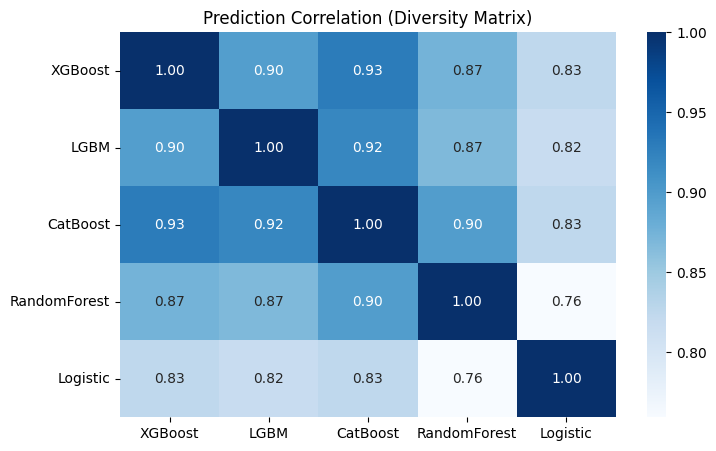

,XGBoost,LGBM,CatBoost,RandomForest,Logistic
XGBoost,1.000000,0.896689,0.930296,0.874538,0.825163
LGBM,0.896689,1.000000,0.919780,0.867815,0.817194
CatBoost,0.930296,0.919780,1.000000,0.898394,0.825163
RandomForest,0.874538,0.867815,0.898394,1.000000,0.759451
Logistic,0.825163,0.817194,0.825163,0.759451,1.000000


In [47]:

analyze_model_correlation(best_estimators, X_test_final[top_cols])

# 8. Creating Ensemble & Model Selection

In [48]:
# X_train = selectedDataSet.drop(target, axis=1)
# y_train = selectedDataSet[target]

In [49]:
from sklearn.ensemble import VotingClassifier, VotingRegressor
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, 
                             roc_auc_score, r2_score, mean_absolute_error, mean_squared_error)
import pandas as pd
import numpy as np

def build_and_evaluate_ensemble(best_estimators, X_test, y_test, task='classification'):
    # 1. Setup Models
    estimators = [(name, model) for name, model in best_estimators.items()]
    y_test_flat = y_test.values.ravel() if hasattr(y_test, 'values') else y_test
    
    if task == 'classification':
        ensemble = VotingClassifier(estimators=estimators, voting='soft')
    else:
        ensemble = VotingRegressor(estimators=estimators)

    # 2. Fit Ensemble
    print(f"⚙️  Fitting Ensemble...")
    ensemble.fit(X_test, y_test_flat)
    
    # 3. Add Ensemble to the dictionary for comparison loop
    all_models = {**best_estimators, '🚀 ENSEMBLE': ensemble}
    performance_data = []

    # 4. Comprehensive Evaluation Loop
    for name, model in all_models.items():
        preds = model.predict(X_test)
        
        if task == 'classification':
            # Handling Probabilities for ROC-AUC
            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(X_test)
                # Select correct AUC logic based on class count
                if probs.shape[1] == 2:
                    auc = roc_auc_score(y_test_flat, probs[:, 1])
                else:
                    auc = roc_auc_score(y_test_flat, probs, multi_class='ovr')
            else:
                auc = np.nan

            performance_data.append({
                'Model': name,
                'Accuracy': accuracy_score(y_test_flat, preds),
                'F1_Weighted': f1_score(y_test_flat, preds, average='weighted'),
                'Precision': precision_score(y_test_flat, preds, average='weighted'),
                'Recall': recall_score(y_test_flat, preds, average='weighted'),
                'ROC_AUC': auc
            })
        else:
            performance_data.append({
                'Model': name,
                'R2': r2_score(y_test_flat, preds),
                'RMSE': np.sqrt(mean_squared_error(y_test_flat, preds)),
                'MAE': mean_absolute_error(y_test_flat, preds)
            })

    # 5. Final Comparison Table
    report_df = pd.DataFrame(performance_data)
    sort_col = 'F1_Weighted' if task == 'classification' else 'R2'
    report_df = report_df.sort_values(by=sort_col, ascending=False)

    print(f"\n🏆 Final Multi-Metric Leaderboard (Sorted by {sort_col}):")
    print(report_df.to_string(index=False))
    
    return ensemble, report_df

In [50]:
my_ensemble, comparison = build_and_evaluate_ensemble(
                            best_estimators, 
                            X_test_final[top_cols], y_test, 
                            task='classification')

⚙️  Fitting Ensemble...

🏆 Final Multi-Metric Leaderboard (Sorted by F1_Weighted):
       Model  Accuracy  F1_Weighted  Precision   Recall  ROC_AUC
  🚀 ENSEMBLE  0.893855     0.893994   0.894192 0.893855 0.947431
RandomForest  0.821229     0.819539   0.819803 0.821229 0.860343
    CatBoost  0.815642     0.816329   0.817483 0.815642 0.853623
    Logistic  0.810056     0.809515   0.809183 0.810056 0.832806
     XGBoost  0.804469     0.805198   0.806386 0.804469 0.852635
        LGBM  0.798883     0.800253   0.803434 0.798883 0.848485


In [51]:
#all
comparison

,Model,Accuracy,F1_Weighted,Precision,Recall,ROC_AUC
5,🚀 ENSEMBLE,0.893855,0.893994,0.894192,0.893855,0.947431
3,RandomForest,0.821229,0.819539,0.819803,0.821229,0.860343
2,CatBoost,0.815642,0.816329,0.817483,0.815642,0.853623
4,Logistic,0.810056,0.809515,0.809183,0.810056,0.832806
0,XGBoost,0.804469,0.805198,0.806386,0.804469,0.852635
1,LGBM,0.798883,0.800253,0.803434,0.798883,0.848485


In [52]:
# dir(best_estimators['CatBoost'])

In [53]:
pd.DataFrame({
    'features':best_estimators['CatBoost'].feature_names_,
    'importance':best_estimators['CatBoost'].feature_importances_}).sort_values('importance',
                                                                           ascending=False)

,features,importance
3,Name_extracted_target,20.352228
8,Pclass_log,11.015393
12,Name_initial_target,10.817278
11,Sex_ohe_female,10.717749
9,Ticket_initial_label,7.066653
4,Pclass_Name_len_ratio_log,6.107519
0,Sex_label,5.980590
14,Fare_bins,4.407587
13,Pclass_Fare_sum_bins,4.176694
7,Name_len_Fare_sum_log,4.058633


# 9. Predicting for test & creating submission file

In [54]:
test_df =  Load_and_Info_DataSet('/kaggle/input/titanic/test.csv')

-------------------------------------------------- 
DataSet Shape:


(418, 11)

-------------------------------------------------- 
DataSet Columns:


Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

-------------------------------------------------- 
DataSet Describe:


...

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

-------------------------------------------------- 
DataSet Sample:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
95,987,3,"Tenglin, Mr. Gunnar Isidor",male,25.0,0,0,350033,7.7958,NaN,S
263,1155,3,"Klasen, Miss. Gertrud Emilia",female,1.0,1,1,350405,12.1833,NaN,S
31,923,2,"Jefferys, Mr. Clifford Thomas",male,24.0,2,0,C.A. 31029,31.5000,NaN,S
410,1302,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
259,1151,3,"Midtsjo, Mr. Karl Albert",male,21.0,0,0,345501,7.7750,NaN,S
386,1278,3,"Aronsson, Mr. Ernst Axel Algot",male,24.0,0,0,349911,7.7750,NaN,S
85,977,3,"Khalil, Mr. Betros",male,NaN,1,0,2660,14.4542,NaN,C
97,989,3,"Makinen, Mr. Kalle Edvard",male,29.0,0,0,STON/O 2. 3101268,7.9250,NaN,S
347,1239,3,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,0,0,2688,7.2292,NaN,C
336,1228,2,"de Brito, Mr. Jose Joaquim",male,32.0,0,0,244360,13.0000,NaN,S


-------------------------------------------------- 
DataSet Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


None

In [55]:
# Engineered_testDf = featureEngineering(test_df)
Engineered_testDf, _ = featureEngineering(test_df, meta_rules=Train_rules)
# X_test_final, _ = featureEngineering(X_test, meta_rules=Train_rules)


🚀 ENGINE START: TESTING
🔍 Phase 1: Mining High-Cardinality Strings...
  > Analyzing 'Name'...
  > Analyzing 'Ticket'...
  > Analyzing 'Cabin'...
🔢 Phase 2: Generating Numeric Interactions...
🛠️ Phase 3: Applying Quad-Stack Encoders...
✅ COMPLETE: 94 Features Created


In [56]:
# missingImputation(Engineered_testDf,'-99999.1111')

In [57]:
required_test_df = Engineered_testDf[top_cols]

In [58]:
print(required_test_df.info())
required_test_df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sex_label                  418 non-null    int64  
 1   Fare_log                   418 non-null    float64
 2   Cabin_initial_target       418 non-null    float64
 3   Name_extracted_target      418 non-null    float64
 4   Pclass_Name_len_ratio_log  418 non-null    float64
 5   Pclass_Fare_ratio_log      418 non-null    float64
 6   Ticket_STON_flag           418 non-null    int64  
 7   Name_len_Fare_sum_log      418 non-null    float64
 8   Pclass_log                 418 non-null    float64
 9   Ticket_initial_label       418 non-null    int64  
 10  Cabin_initial_label        418 non-null    int64  
 11  Sex_ohe_female             418 non-null    int64  
 12  Name_initial_target        418 non-null    float64
 13  Pclass_Fare_sum_bins       418 non-null    int64  

,Sex_label,Fare_log,Cabin_initial_target,Name_extracted_target,Pclass_Name_len_ratio_log,Pclass_Fare_ratio_log,Ticket_STON_flag,Name_len_Fare_sum_log,Pclass_log,Ticket_initial_label,Cabin_initial_label,Sex_ohe_female,Name_initial_target,Pclass_Fare_sum_bins,Fare_bins,Name_initial_ohe_D
59,2,5.573579,0.655324,0.681022,0.036368,0.003804,0,5.671173,0.693147,3,7,1,0.388035,5,5,0
388,1,2.169054,0.293299,0.158375,0.139762,0.327213,0,3.358638,1.386294,4,1,0,0.388035,0,0,0
244,1,3.196630,0.293299,0.508153,0.070618,0.120386,0,4.181286,1.386294,13,1,0,0.300952,3,3,0
64,1,5.573579,0.655324,0.508153,0.036368,0.003804,0,5.671173,0.693147,3,7,0,0.309047,5,5,0
211,1,2.085672,0.293299,0.158375,0.162519,0.354545,0,3.220874,1.386294,9,1,0,0.377479,0,0,0


### Creating Submission File

In [59]:
best_estimators.keys()

dict_keys(['XGBoost', 'LGBM', 'CatBoost', 'RandomForest', 'Logistic'])

In [60]:
predictions_ensemble = my_ensemble.predict(required_test_df)
predictions_catBoost = best_estimators['CatBoost'].predict(required_test_df)
predictions_xgb = best_estimators['XGBoost'].predict(required_test_df)
predictions_LGBM = best_estimators['LGBM'].predict(required_test_df)
prediction_RF = best_estimators['RandomForest'].predict(required_test_df)

In [61]:
pd.DataFrame({
                'PassengerId': test_df['PassengerId'],
                target : predictions_ensemble
}).to_csv('submission.csv',index=False)